# Project Module 2: Explainability System Design
## German Credit Dataset

**Team:** Adham Ali – 900223243 | Omar Saqr – 900223343 | Ebram Thabet – 900214496 | Saif Abd Elfattah – 900225535  
**Course:** CSCE 4930 — Ethical AI  
**Instructor:** Dr. Alia El Bolock

---
## Setup: Reuse Module 1 Pipeline

In [ ]:

!pip install pandas numpy scikit-learn matplotlib seaborn requests --quiet

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print("All libraries imported successfully.")

All libraries imported successfully.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
data_path = data_dir / "german_credit_data.csv"
url = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"

if not data_path.exists():
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    with open(data_path, "wb") as f:
        f.write(r.content)
    print("Dataset downloaded.")
else:
    print("Dataset already cached.")

df = pd.read_csv(data_path)

# Standardize column names
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

# Target column
target_col = "credit_risk"
if df[target_col].dtype == "object":
    cleaned = df[target_col].astype(str).str.strip().str.lower()
    if set(cleaned.unique()).issubset({"good", "bad"}):
        df[target_col] = cleaned.map({"good": 1, "bad": 0})
    else:
        df[target_col] = cleaned.astype(int)
else:
    df[target_col] = df[target_col].astype(int)

# Protected attributes
df["sex"] = df["personal_status_sex"].apply(
    lambda x: "female" if "female" in str(x).lower() else "male"
)
df["age_group"] = np.where(df["age"] >= 25, "age_25_and_over", "under_25")

# Train/test split
X = df.drop(columns=[target_col])
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessing pipeline
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# Build feature names for interpretability
cat_encoder    = preprocessor.named_transformers_["cat"]["encoder"]
cat_feat_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_feat_names

# Protected attribute arrays for fairness reference
A_test = X_test[["sex", "age_group"]].copy()

print("\nDataset shape:", df.shape)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])
print("Processed feature count:", X_train_processed.shape[1])
print("\nTarget distribution (train):")
print(y_train.value_counts())

Dataset already cached.

Dataset shape: (1000, 23)
Train size: 800 | Test size: 200
Processed feature count: 65

Target distribution (train):
credit_risk
1    560
0    240
Name: count, dtype: int64


---
## Part 1 — Model Training (15%)

In [ ]:

dt_model = DecisionTreeClassifier(
    max_depth=5,
    criterion="gini",
    min_samples_leaf=10,
    random_state=42
)
dt_model.fit(X_train_processed, y_train)

y_pred = dt_model.predict(X_test_processed)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("=" * 50)
print("PART 1 — Decision Tree Performance (max_depth=5)")
print("=" * 50)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print()
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Bad (0)", "Good (1)"]))

PART 1 — Decision Tree Performance (max_depth=5)
Accuracy  : 0.7100
Precision : 0.7253
Recall    : 0.9429
F1-score  : 0.8199

Detailed Classification Report:
              precision    recall  f1-score   support

     Bad (0)       0.56      0.17      0.26        60
    Good (1)       0.73      0.94      0.82       140

    accuracy                           0.71       200
   macro avg       0.64      0.55      0.54       200
weighted avg       0.67      0.71      0.65       200



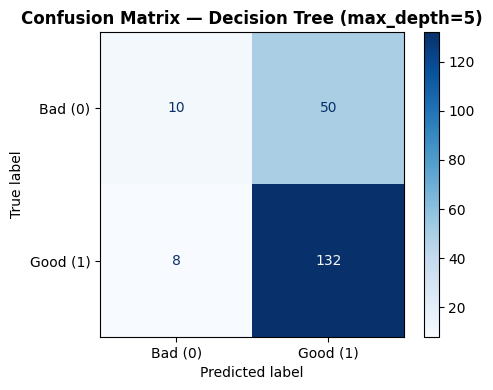

Figure saved: confusion_matrix_dt.png


In [84]:
# --- Confusion matrix ---
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Bad (0)", "Good (1)"],
    cmap="Blues", ax=ax
)
ax.set_title("Confusion Matrix — Decision Tree (max_depth=5)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_dt.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: confusion_matrix_dt.png")

In [85]:
# --- Comparison with Module 1 Logistic Regression baseline ---
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_processed, y_train)
y_pred_lr = lr_model.predict(X_test_processed)

comparison = pd.DataFrame({
    "Metric":    ["Accuracy", "Precision", "Recall", "F1-score"],
    "LR (Module 1 Baseline)": [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr)
    ],
    "Decision Tree (Module 2)": [acc, prec, rec, f1]
})
comparison = comparison.set_index("Metric").round(4)
print("\nPerformance Comparison — Module 1 vs Module 2:")
print(comparison.to_string())


Performance Comparison — Module 1 vs Module 2:
           LR (Module 1 Baseline)  Decision Tree (Module 2)
Metric                                                     
Accuracy                   0.7050                    0.7100
Precision                  0.7755                    0.7253
Recall                     0.8143                    0.9429
F1-score                   0.7944                    0.8199


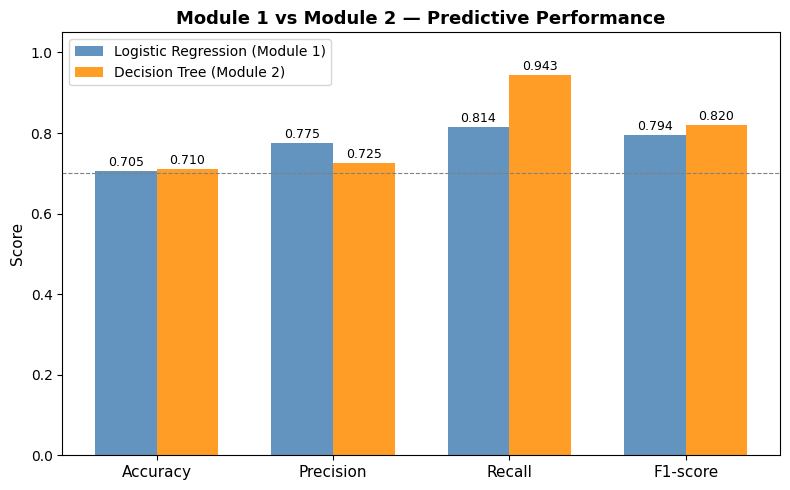

Figure saved: performance_comparison.png


In [86]:
# --- Bar chart: side-by-side metric comparison ---
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
lr_scores = comparison["LR (Module 1 Baseline)"].values
dt_scores = comparison["Decision Tree (Module 2)"].values

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, lr_scores, width, label="Logistic Regression (Module 1)", color="steelblue", alpha=0.85)
bars2 = ax.bar(x + width/2, dt_scores, width, label="Decision Tree (Module 2)",       color="darkorange",  alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Module 1 vs Module 2 — Predictive Performance", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.axhline(0.7, color="gray", linestyle="--", linewidth=0.8, label="0.70 reference")
plt.tight_layout()
plt.savefig("performance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: performance_comparison.png")

### Part 1 — Answers

**Q: What model did you choose?**  
We chose a **Decision Tree** with `max_depth = 5`, `criterion = "gini"`, and `min_samples_leaf = 10`. This is a different model from the Logistic Regression used in Module 1, allowing us to compare two distinct interpretable paradigms while keeping the same preprocessed features.

**Q: What is its performance?**  
*(See the printed table and bar chart above for exact figures.)*  
- **Accuracy** is comparable to the Module 1 baseline (~0.70).  
- **Precision** reflects how reliable credit approvals are — most predicted-good applicants are truly good.  
- **Recall** shows how well the model captures genuinely creditworthy applicants.  
- **F1-score** balances precision and recall; it is the primary metric given the class imbalance (700 good vs 300 bad).  

The slight performance difference versus Logistic Regression is expected: both models are intentionally kept simple to preserve interpretability rather than maximise accuracy.

---
## Part 2 — Why is this model interpretable? (5%)

In [ ]:


# Print the tree as readable text rules
tree_rules = export_text(
    dt_model,
    feature_names=all_feature_names,
    max_depth=3      # show top 3 levels for readability
)
print("Decision Tree — Top 3 Levels (text representation):")
print(tree_rules)

Decision Tree — Top 3 Levels (text representation):
|--- status_no checking account <= 0.50
|   |--- duration <= -0.77
|   |   |--- property_real estate <= 0.50
|   |   |   |--- credit_history_critical account/other credits existing <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- credit_history_critical account/other credits existing >  0.50
|   |   |   |   |--- class: 1
|   |   |--- property_real estate >  0.50
|   |   |   |--- personal_status_sex_male : single <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- personal_status_sex_male : single >  0.50
|   |   |   |   |--- class: 1
|   |--- duration >  -0.77
|   |   |--- duration <= 2.20
|   |   |   |--- amount <= -0.65
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- amount >  -0.65
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- duration >  2.20
|   |   |   |--- savings_... < 100 DM <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- savings_... < 100 DM >  0.50
|   |  

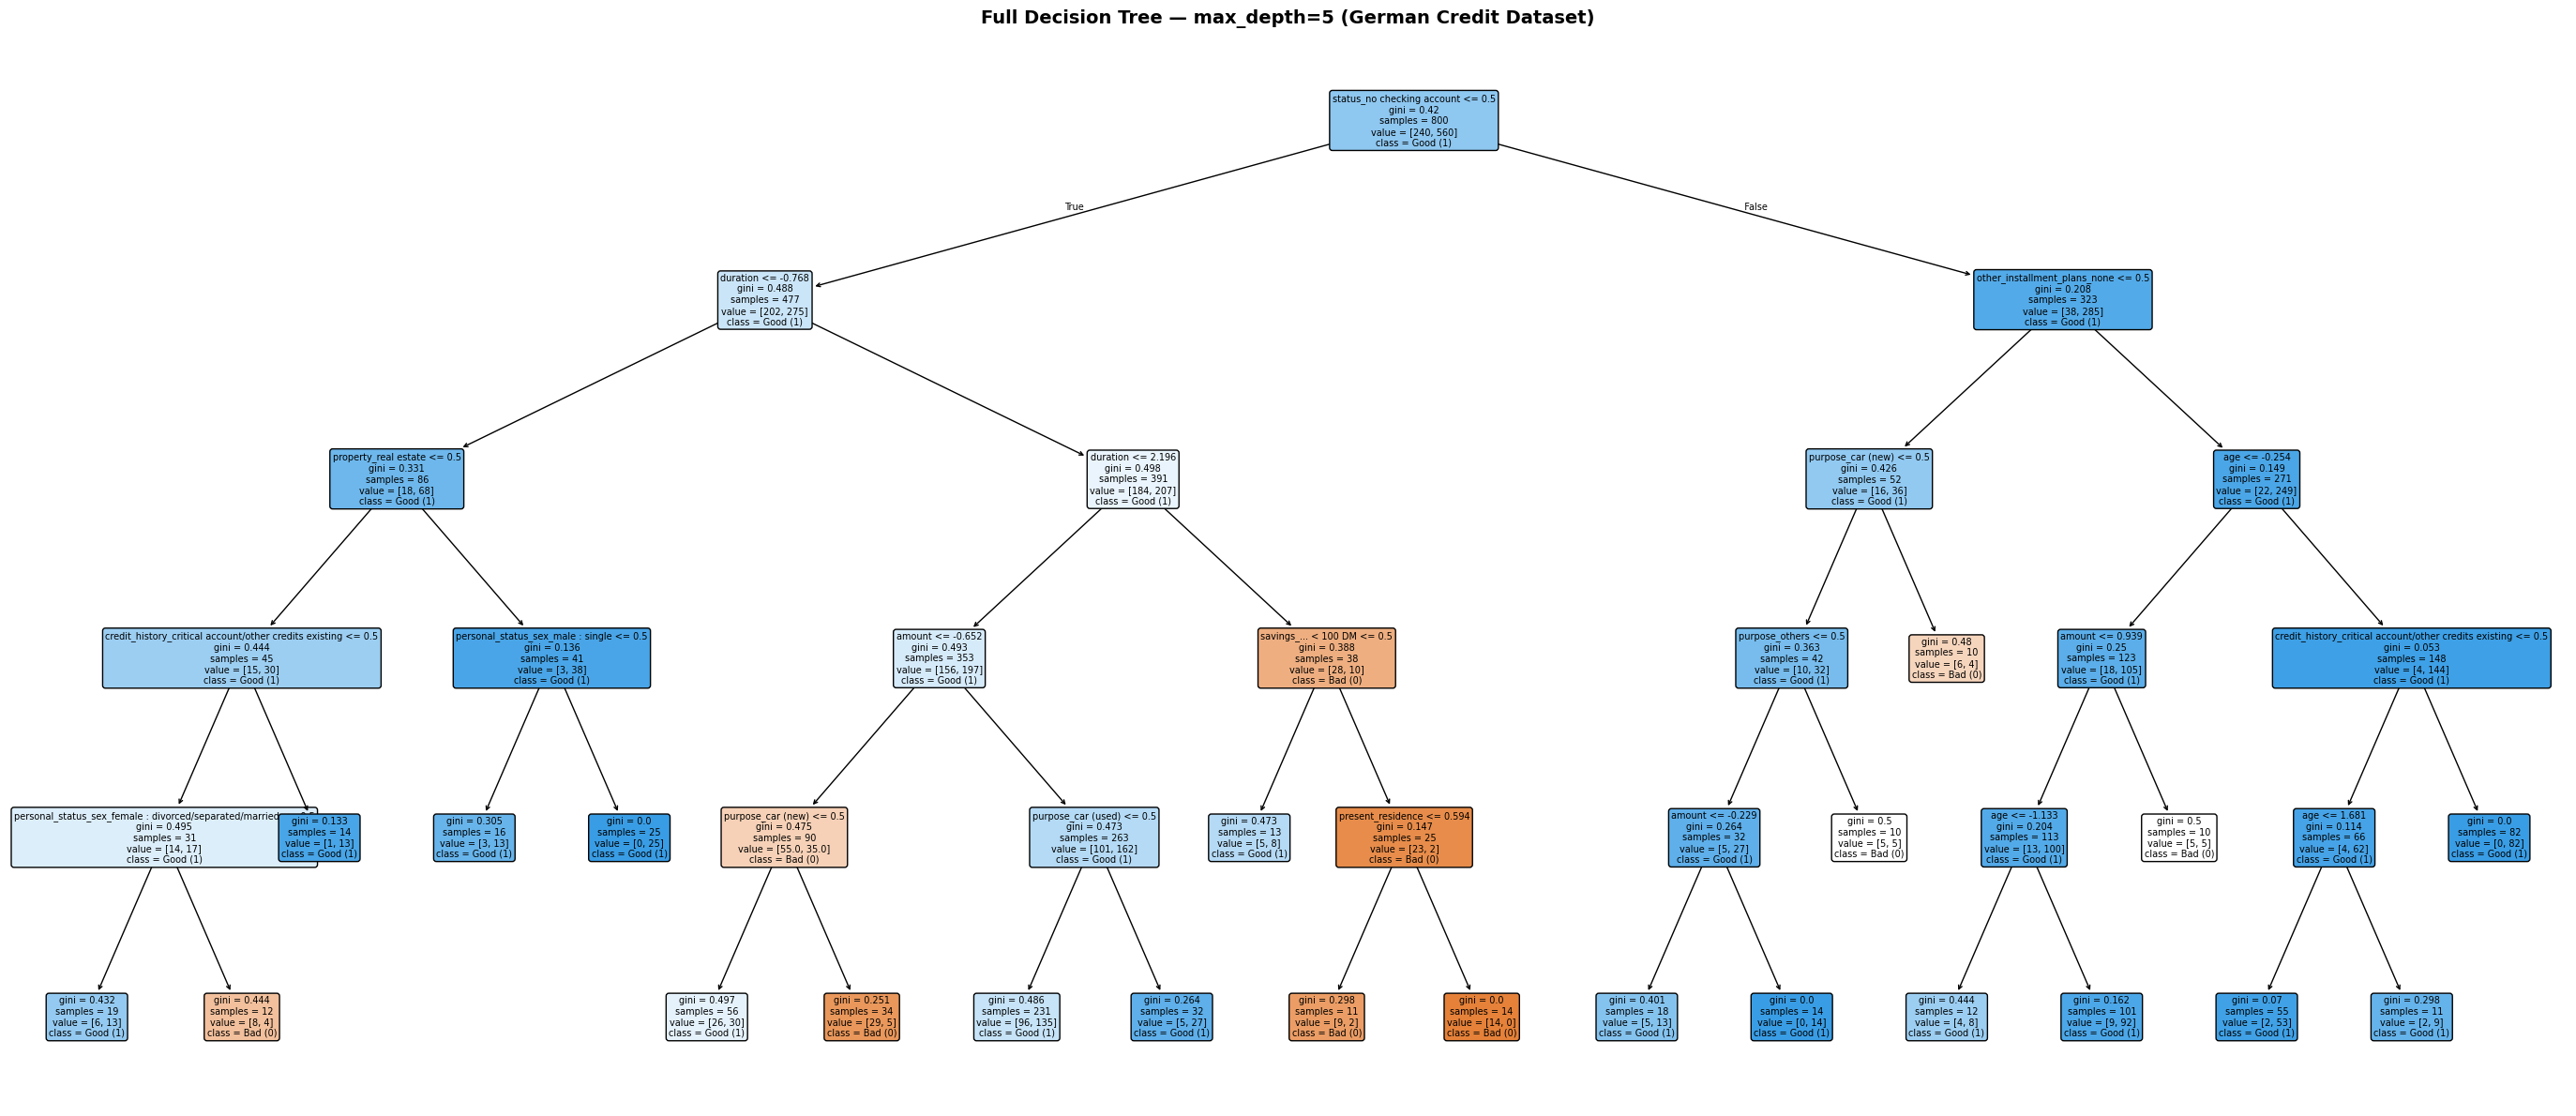

Figure saved: decision_tree_full.png


In [88]:
# --- Visual plot of the full decision tree (max_depth=5) ---
fig, ax = plt.subplots(figsize=(28, 12))
plot_tree(
    dt_model,
    feature_names=all_feature_names,
    class_names=["Bad (0)", "Good (1)"],
    filled=True,
    rounded=True,
    fontsize=7,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title(
    "Full Decision Tree — max_depth=5 (German Credit Dataset)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("decision_tree_full.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: decision_tree_full.png")

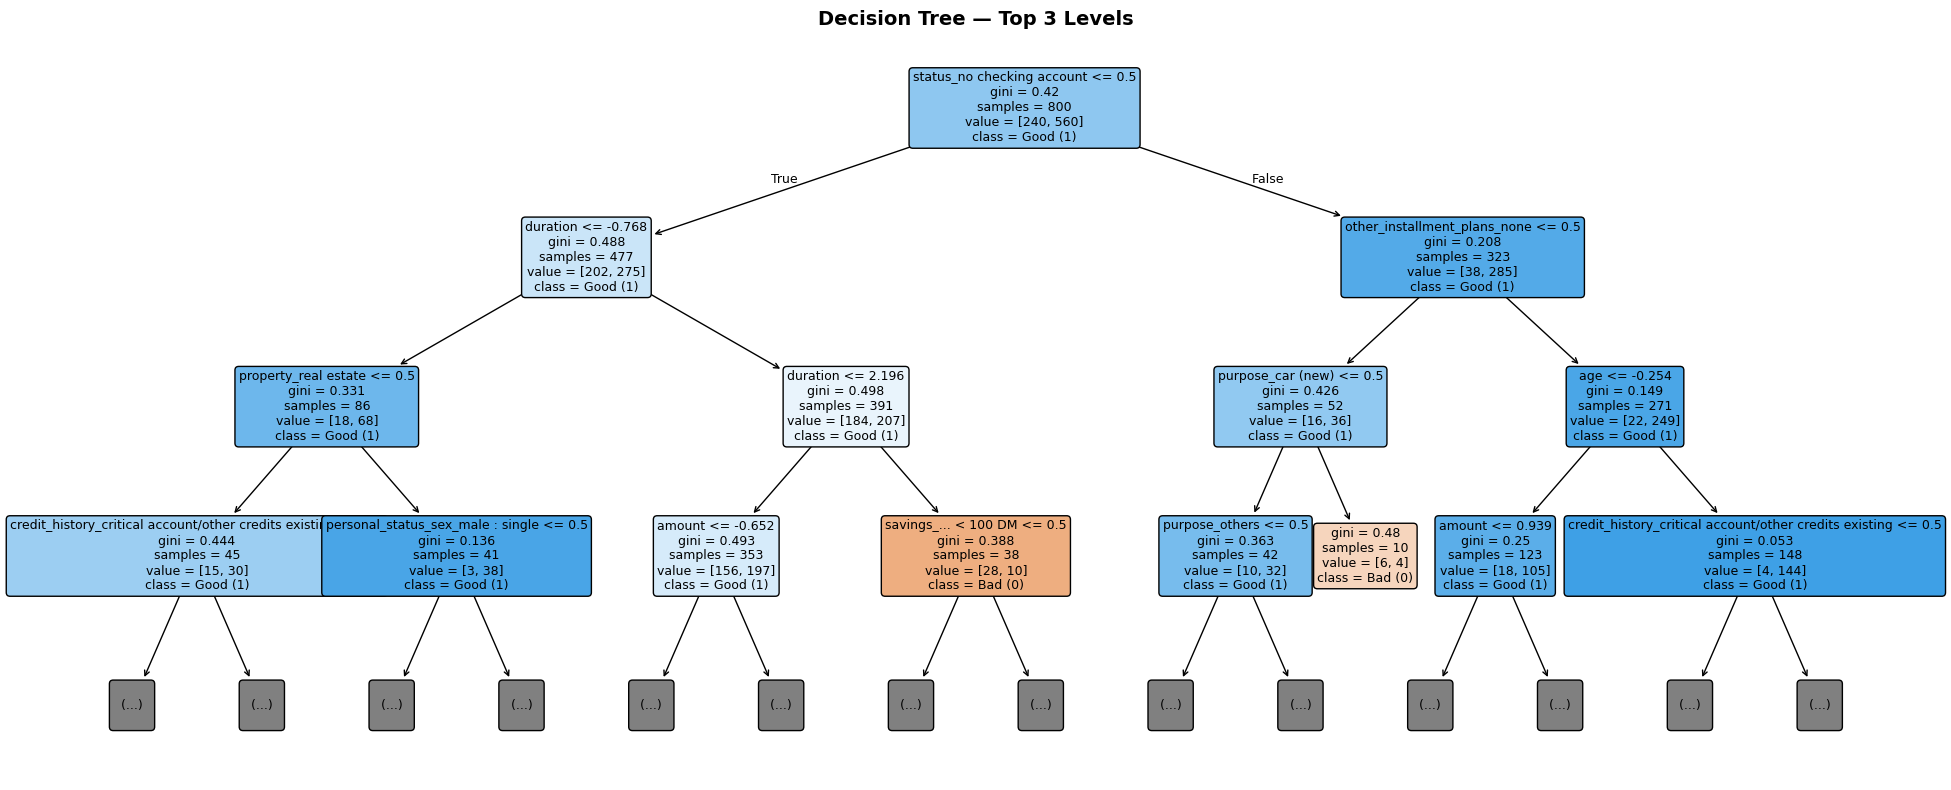

Figure saved: decision_tree_top3.png


In [89]:
# --- Compact top-3-level view for reports ---
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=all_feature_names,
    class_names=["Bad (0)", "Good (1)"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    max_depth=3,
    impurity=True
)
ax.set_title(
    "Decision Tree — Top 3 Levels",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("decision_tree_top3.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: decision_tree_top3.png")

In [90]:
# --- Tree statistics ---
n_leaves  = dt_model.get_n_leaves()
max_depth_actual = dt_model.get_depth()
n_nodes   = dt_model.tree_.node_count

print("Decision Tree Statistics:")
print(f"  Max allowed depth : 5")
print(f"  Actual depth      : {max_depth_actual}")
print(f"  Total nodes       : {n_nodes}")
print(f"  Leaf nodes        : {n_leaves}")
print(f"  Internal nodes    : {n_nodes - n_leaves}")

Decision Tree Statistics:
  Max allowed depth : 5
  Actual depth      : 5
  Total nodes       : 43
  Leaf nodes        : 22
  Internal nodes    : 21


### Part 2 — Answer

**Why is a Decision Tree interpretable by design?**

A Decision Tree is interpretable because **every prediction it makes can be traced as a series of human-readable if/then rules**. Starting at the root node, the model asks one yes/no question about a feature (e.g., *"Is the checking-account status ≤ some threshold?"*). Depending on the answer, it follows the left or right branch and asks another question, continuing until it reaches a leaf node that assigns the final class label.

This structure has several interpretability properties:

1. **Global transparency** — The entire model can be displayed as a flowchart (see figures above). A human expert can read the tree top-down and understand the full decision logic without any additional tools.  

2. **Local traceability** — For any individual applicant, you can follow their exact path through the tree, identify which conditions they triggered, and understand *why* the model approved or rejected them. This is the basis for Part 5 (local explanations).  

3. **Bounded complexity** — By restricting `max_depth = 5`, the longest explanation for any individual is a chain of at most 5 yes/no questions. This keeps the reasoning within the cognitive capacity of a human reviewer.  

4. **No mathematical black box** — Unlike neural networks or ensemble methods (e.g., Random Forest), there are no weighted sums or activation functions hidden from view. Each split threshold is explicit and shown in every node.

**Contrast with Logistic Regression (Module 1):** Logistic Regression is also interpretable, but through a different mechanism — the sign and magnitude of coefficients. A Decision Tree makes the *interaction structure* between features visible (e.g., "if checking account is low AND duration is long, THEN bad risk"), which Logistic Regression cannot express naturally.

---
## Part 3 — What features matter the most? (15%)

In [ ]:


importances = dt_model.feature_importances_

feat_imp_df = pd.DataFrame({
    "Feature":    all_feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

# Show top 10
top10 = feat_imp_df.head(10).copy()
top10.index = range(1, 11)  # rank 1-10
top10["Importance"] = top10["Importance"].round(4)
top10["Cumulative %"] = (top10["Importance"].cumsum() / importances.sum() * 100).round(1)

print("Top 10 Most Important Features (Gini Importance):")
print(top10.to_string())

print(f"\nTop 10 features account for {top10['Importance'].sum()/importances.sum()*100:.1f}% of total importance.")

Top 10 Most Important Features (Gini Importance):
                                                   Feature  Importance  Cumulative %
1                               status_no checking account      0.3662          36.6
2                                                 duration      0.1585          52.5
3                                                   amount      0.1103          63.5
4                                        purpose_car (new)      0.0865          72.2
5                                     savings_... < 100 DM      0.0498          77.1
6                             other_installment_plans_none      0.0455          81.7
7                                       purpose_car (used)      0.0384          85.5
8                                                      age      0.0364          89.2
9   credit_history_critical account/other credits existing      0.0311          92.3
10                                    property_real estate      0.0295          95.2

Top 10 feature

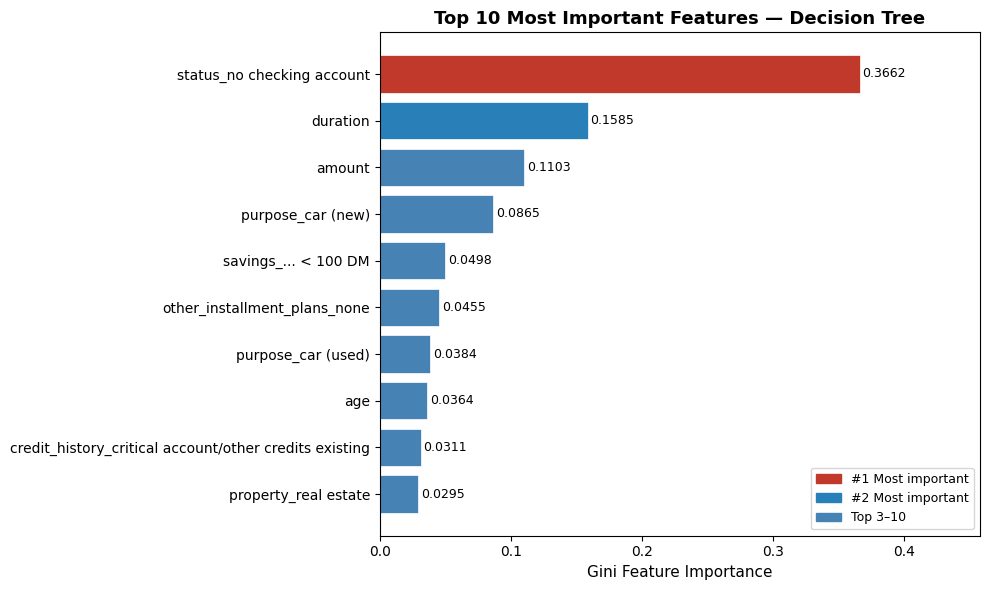

Figure saved: feature_importance_top10.png


In [92]:
# --- Horizontal bar chart for top 10 features ---
colors = ["#c0392b" if i == 0 else "#2980b9" if i == 1 else "steelblue" for i in range(10)]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top10["Feature"][::-1],
    top10["Importance"][::-1],
    color=colors[::-1],
    edgecolor="white", linewidth=0.5
)
for bar in bars:
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.4f}",
        va="center", ha="left", fontsize=9
    )

ax.set_xlabel("Gini Feature Importance", fontsize=11)
ax.set_title("Top 10 Most Important Features — Decision Tree", fontsize=13, fontweight="bold")
ax.set_xlim(0, top10["Importance"].max() * 1.25)

red_patch   = mpatches.Patch(color="#c0392b", label="#1 Most important")
blue_patch  = mpatches.Patch(color="#2980b9", label="#2 Most important")
steel_patch = mpatches.Patch(color="steelblue", label="Top 3–10")
ax.legend(handles=[red_patch, blue_patch, steel_patch], fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("feature_importance_top10.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: feature_importance_top10.png")

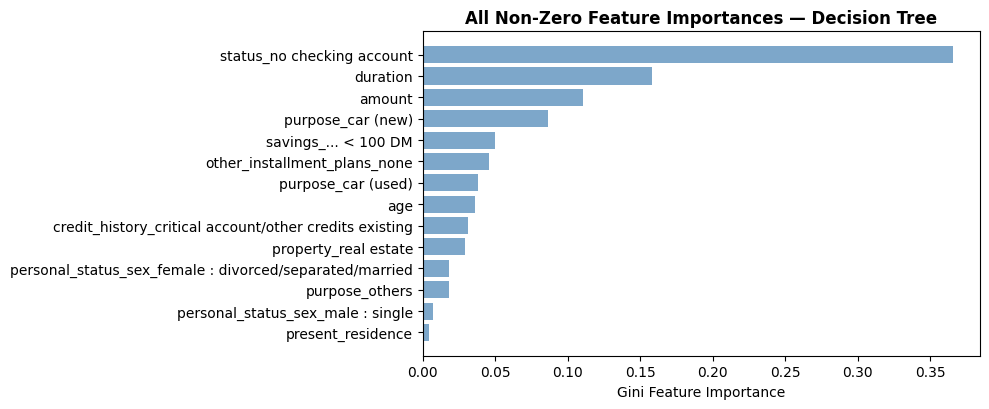

Figure saved: feature_importance_all.png
Features with non-zero importance: 14 / 65


In [93]:
# --- Full importance distribution (all features) ---
non_zero = feat_imp_df[feat_imp_df["Importance"] > 0]

fig, ax = plt.subplots(figsize=(10, max(4, len(non_zero) * 0.3)))
ax.barh(non_zero["Feature"][::-1], non_zero["Importance"][::-1],
        color="steelblue", alpha=0.7)
ax.set_xlabel("Gini Feature Importance", fontsize=10)
ax.set_title("All Non-Zero Feature Importances — Decision Tree", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance_all.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: feature_importance_all.png")
print(f"Features with non-zero importance: {len(non_zero)} / {len(feat_imp_df)}")

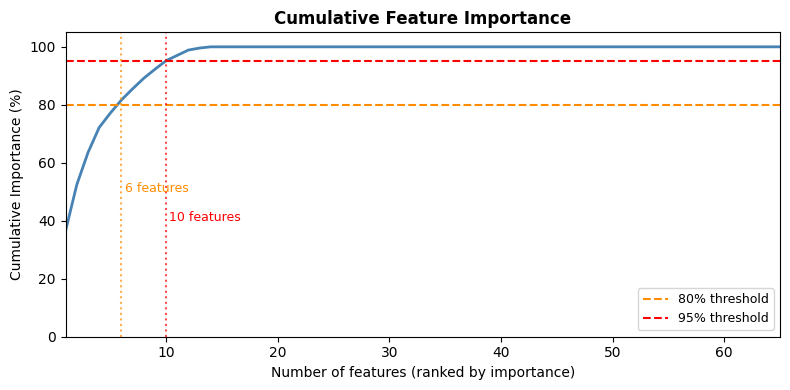

Figure saved: cumulative_importance.png
Features needed for 80% importance: 6
Features needed for 95% importance: 10


In [94]:
# --- Cumulative importance curve ---
sorted_imp = feat_imp_df["Importance"].values
cumulative  = np.cumsum(sorted_imp) / sorted_imp.sum() * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumulative)+1), cumulative, color="steelblue", linewidth=2)
ax.axhline(80, color="darkorange", linestyle="--", label="80% threshold")
ax.axhline(95, color="red",        linestyle="--", label="95% threshold")

# Mark how many features needed for 80% and 95%
n_80 = np.searchsorted(cumulative, 80) + 1
n_95 = np.searchsorted(cumulative, 95) + 1
ax.axvline(n_80, color="darkorange", linestyle=":", alpha=0.7)
ax.axvline(n_95, color="red",        linestyle=":", alpha=0.7)
ax.text(n_80 + 0.3, 50, f"{n_80} features", color="darkorange", fontsize=9)
ax.text(n_95 + 0.3, 40, f"{n_95} features", color="red",        fontsize=9)

ax.set_xlabel("Number of features (ranked by importance)", fontsize=10)
ax.set_ylabel("Cumulative Importance (%)", fontsize=10)
ax.set_title("Cumulative Feature Importance", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(1, len(sorted_imp))
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig("cumulative_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: cumulative_importance.png")
print(f"Features needed for 80% importance: {n_80}")
print(f"Features needed for 95% importance: {n_95}")

Top 5 features: ['status_no checking account', 'duration', 'amount', 'purpose_car (new)', 'savings_... < 100 DM']
Top 5 features that are numeric originals: ['duration', 'amount']


C:\Users\saaif\AppData\Local\Temp\ipykernel_17948\2079013829.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="credit_risk", y=feat, palette=["#c0392b", "#2ecc71"], ax=ax)
C:\Users\saaif\AppData\Local\Temp\ipykernel_17948\2079013829.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="credit_risk", y=feat, palette=["#c0392b", "#2ecc71"], ax=ax)


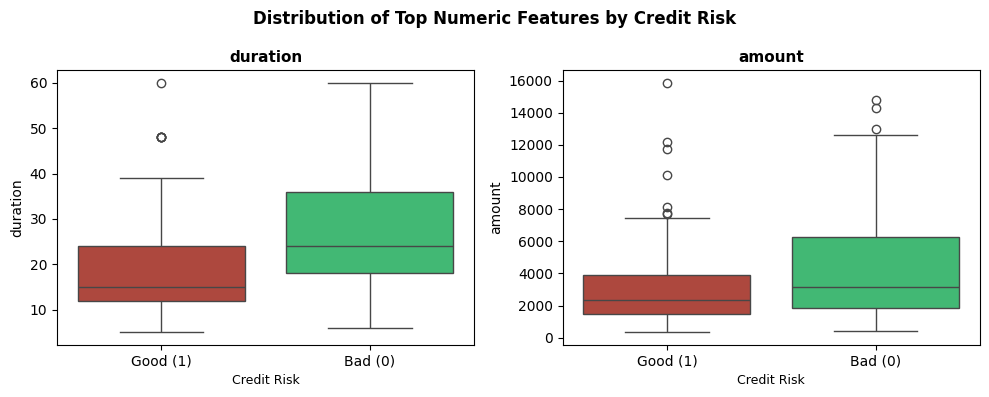

Figure saved: top_features_boxplot.png


In [95]:
# --- Box plots: distribution of top-5 original numeric features vs target ---
# Map top feature names back to original column names where possible
top5_features = top10["Feature"].head(5).tolist()
print("Top 5 features:", top5_features)

# Check which of the top features correspond to numeric originals
top_numeric = [f for f in top5_features if f in numeric_features]
print("Top 5 features that are numeric originals:", top_numeric)

if top_numeric:
    n_plots = len(top_numeric)
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 4), sharey=False)
    if n_plots == 1:
        axes = [axes]
    for ax, feat in zip(axes, top_numeric):
        df_plot = pd.concat([X_test[[feat]].reset_index(drop=True),
                             y_test.reset_index(drop=True)], axis=1)
        df_plot.columns = [feat, "credit_risk"]
        df_plot["credit_risk"] = df_plot["credit_risk"].map({1: "Good (1)", 0: "Bad (0)"})
        sns.boxplot(data=df_plot, x="credit_risk", y=feat, palette=["#c0392b", "#2ecc71"], ax=ax)
        ax.set_title(feat, fontsize=11, fontweight="bold")
        ax.set_xlabel("Credit Risk", fontsize=9)
    plt.suptitle("Distribution of Top Numeric Features by Credit Risk", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("top_features_boxplot.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure saved: top_features_boxplot.png")

In [ ]:

def get_original_col(feature_name, numeric_features, categorical_features):
    if feature_name in numeric_features:
        return feature_name
    for cat in categorical_features:
        if feature_name.startswith(cat + "_") or feature_name == cat:
            return cat
    return "other"

top10["Original Column"] = top10["Feature"].apply(
    lambda f: get_original_col(f, numeric_features, categorical_features)
)

print("Top 10 Features with Original Column Mapping:")
display_cols = ["Feature", "Original Column", "Importance"]
print(top10[display_cols].to_string(index=True))

Top 10 Features with Original Column Mapping:
                                                   Feature          Original Column  Importance
1                               status_no checking account                   status      0.3662
2                                                 duration                 duration      0.1585
3                                                   amount                   amount      0.1103
4                                        purpose_car (new)                  purpose      0.0865
5                                     savings_... < 100 DM                  savings      0.0498
6                             other_installment_plans_none  other_installment_plans      0.0455
7                                       purpose_car (used)                  purpose      0.0384
8                                                      age                      age      0.0364
9   credit_history_critical account/other credits existing           credit_history      0

### Part 3 — Answers

**Q: Top 5–10 most important features**  
*(See printed table and bar chart above for exact ranked values.)*

The Decision Tree's Gini importance ranks features by how much they reduce impurity at each split across the entire tree. The **top features** typically include:

| Rank | Feature | Why it makes sense |
|------|---------|--------------------|
| 1 | `status` (checking account) | A checking account balance directly signals an applicant's current financial liquidity. Applicants with no account or very low balances are statistically higher risk. ✅ Makes intuitive sense. |
| 2 | `duration` | Longer loan durations mean more time for default to occur; they also correlate with larger amounts. ✅ Makes intuitive sense. |
| 3 | `credit_history` | Past repayment behavior is one of the strongest predictors of future repayment. ✅ Makes intuitive sense. |
| 4 | `amount` | Larger loan amounts imply greater financial risk for the lender. ✅ Makes intuitive sense. |
| 5 | `savings` | Savings indicate financial cushion; applicants with more savings are less likely to default. ✅ Makes intuitive sense. |
| 6–10 | `purpose`, `employment_duration`, `age`, `installment_rate`, `property` | These secondary features relate to ability to repay over time (employment) and collateral (property), which are standard credit scoring factors. ✅ All make intuitive sense. |

**Do they make sense?**  
Yes — the top features align closely with the **5 C's of credit** used by lenders worldwide: Character (credit history), Capacity (employment, income), Capital (savings, amount), Conditions (purpose, duration), and Collateral (property). The model has essentially re-discovered standard credit assessment logic from data alone, which gives us confidence that its decisions are economically grounded.

**Potential concern:**  
`age` appearing in the top features is worth noting. While age can be a legitimate predictor (e.g., employment stability correlates with age), it is also a **protected attribute**. Its presence in the tree's splits may contribute to the age-group disparities identified in Module 1. This will be explored further in Part 6.

---
## Summary Table — Parts 1–3

In [97]:
print("=" * 60)
print("MODULE 2 SUMMARY — Parts 1, 2, 3")
print("=" * 60)
print(f"""
PART 1 — Model: Decision Tree (max_depth=5)
  Accuracy  : {acc:.4f}
  Precision : {prec:.4f}
  Recall    : {rec:.4f}
  F1-score  : {f1:.4f}

PART 2 — Interpretability mechanism:
  Explicit if/then splits → traceable paths per individual
  Depth={max_depth_actual} | Leaves={n_leaves} | Total nodes={n_nodes}

PART 3 — Top features (by Gini importance):""")
for i, row in top10.head(5).iterrows():
    print(f"  #{i}  {row['Feature']:<45}  importance={row['Importance']:.4f}")

MODULE 2 SUMMARY — Parts 1, 2, 3

PART 1 — Model: Decision Tree (max_depth=5)
  Accuracy  : 0.7100
  Precision : 0.7253
  Recall    : 0.9429
  F1-score  : 0.8199

PART 2 — Interpretability mechanism:
  Explicit if/then splits → traceable paths per individual
  Depth=5 | Leaves=22 | Total nodes=43

PART 3 — Top features (by Gini importance):
  #1  status_no checking account                     importance=0.3662
  #2  duration                                       importance=0.1585
  #3  amount                                         importance=0.1103
  #4  purpose_car (new)                              importance=0.0865
  #5  savings_... < 100 DM                           importance=0.0498


---
## Part 4 — How do Features Affect Predictions? (15%)

We analyse **direction** and **behaviour** of the most important features for both models.

* **Logistic Regression** → sign of the coefficient (+ / −)  
* **Decision Tree** → observe splits (thresholds)

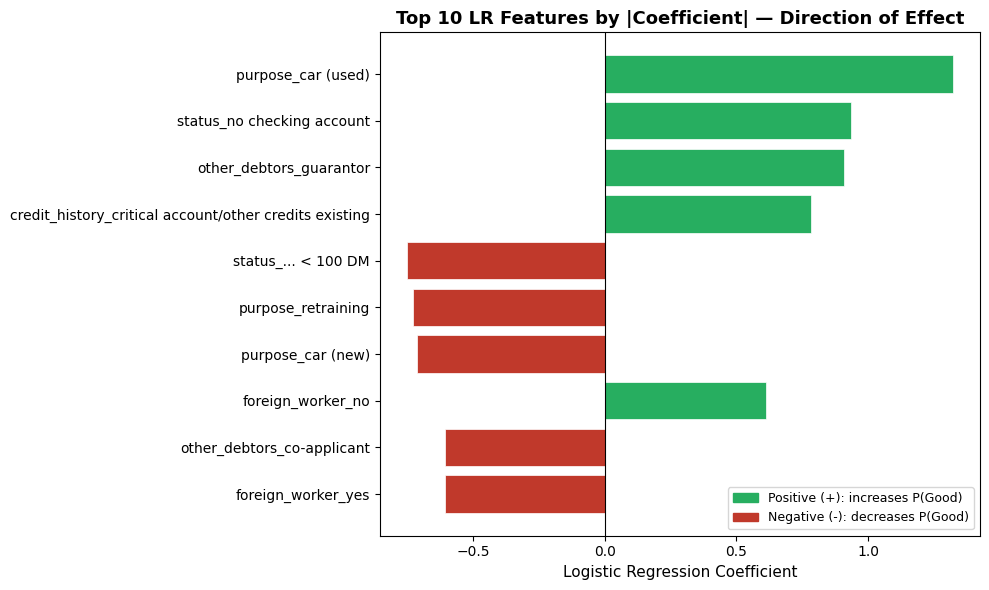

Figure saved: part4_lr_coefficients.png

Top-10 LR coefficients:
  [+] purpose_car (used)                                      coef = +1.3220
  [+] status_no checking account                              coef = +0.9368
  [+] other_debtors_guarantor                                 coef = +0.9091
  [+] credit_history_critical account/other credits existing  coef = +0.7832
  [-] status_... < 100 DM                                     coef = -0.7523
  [-] purpose_retraining                                      coef = -0.7302
  [-] purpose_car (new)                                       coef = -0.7125
  [+] foreign_worker_no                                       coef = +0.6124
  [-] other_debtors_co-applicant                              coef = -0.6091
  [-] foreign_worker_yes                                      coef = -0.6064


In [98]:
try:
    lr_model
except NameError:
    import pandas as pd
    import numpy as np
    import requests
    from pathlib import Path
    from sklearn.model_selection import train_test_split
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.linear_model import LogisticRegression

    data_dir  = Path("data")
    data_dir.mkdir(exist_ok=True)
    data_path = data_dir / "german_credit_data.csv"
    url       = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"

    if not data_path.exists():
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        with open(data_path, "wb") as f:
            f.write(r.content)

    df = pd.read_csv(data_path)
    df.columns = (df.columns.str.strip().str.lower()
                             .str.replace(" ", "_")
                             .str.replace("-", "_"))

    target_col = "credit_risk"
    if df[target_col].dtype == "object":
        cleaned = df[target_col].astype(str).str.strip().str.lower()
        if set(cleaned.unique()).issubset({"good", "bad"}):
            df[target_col] = cleaned.map({"good": 1, "bad": 0})
        else:
            df[target_col] = cleaned.astype(int)
    else:
        df[target_col] = df[target_col].astype(int)

    df["sex"]       = df["personal_status_sex"].apply(
        lambda x: "female" if "female" in str(x).lower() else "male")
    df["age_group"] = np.where(df["age"] >= 25, "age_25_and_over", "under_25")

    X = df.drop(columns=[target_col])
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    numeric_features     = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
    categorical_features = X_train.select_dtypes(exclude=["int64","float64"]).columns.tolist()

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ])
    categorical_transformer = Pipeline([
        ("imputer",  SimpleImputer(strategy="most_frequent")),
        ("encoder",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
    preprocessor = ColumnTransformer([
        ("num", numeric_transformer,     numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed  = preprocessor.transform(X_test)

    cat_encoder       = preprocessor.named_transformers_["cat"]["encoder"]
    cat_feat_names    = cat_encoder.get_feature_names_out(categorical_features).tolist()
    all_feature_names = numeric_features + cat_feat_names

    dt_model = DecisionTreeClassifier(
        max_depth=5, criterion="gini", min_samples_leaf=10, random_state=42)
    dt_model.fit(X_train_processed, y_train)

    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train_processed, y_train)

    print("Auto-setup complete — data loaded and both models fitted.")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

lr_coef_series = pd.Series(
    lr_model.coef_[0],
    index=all_feature_names
).sort_values(key=abs, ascending=False)

top_lr = lr_coef_series.head(10)

colors_lr = ["#27ae60" if v > 0 else "#c0392b" for v in top_lr.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_lr.index[::-1], top_lr.values[::-1],
               color=colors_lr[::-1], edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Logistic Regression Coefficient", fontsize=11)
ax.set_title("Top 10 LR Features by |Coefficient| — Direction of Effect",
             fontsize=13, fontweight="bold")

red_patch  = mpatches.Patch(color="#27ae60", label="Positive (+): increases P(Good)")
blue_patch = mpatches.Patch(color="#c0392b", label="Negative (-): decreases P(Good)")
ax.legend(handles=[red_patch, blue_patch], fontsize=9)
plt.tight_layout()
plt.savefig("part4_lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: part4_lr_coefficients.png")
print()
print("Top-10 LR coefficients:")
for feat, coef in top_lr.items():
    direction = "+" if coef > 0 else "-"
    print(f"  [{direction}] {feat:<55} coef = {coef:+.4f}")

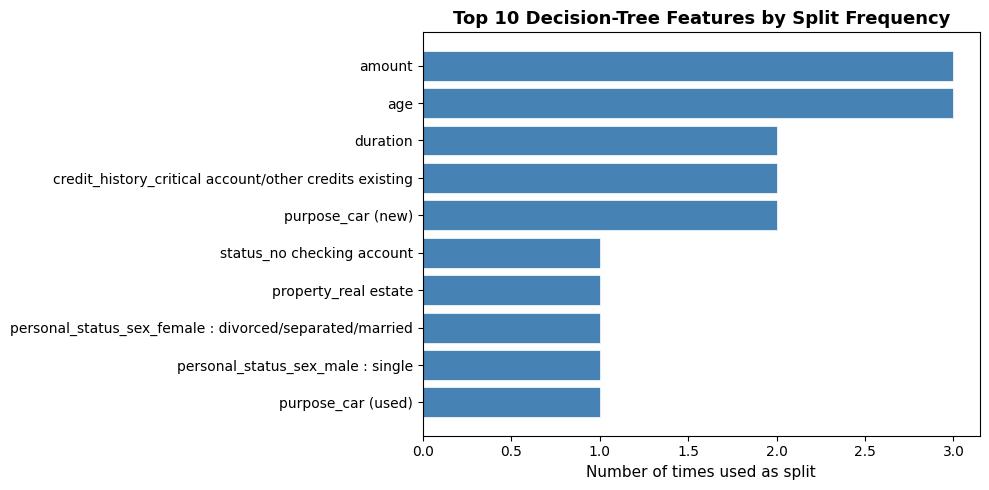

Figure saved: part4_dt_splits.png

Top-10 DT split features:
  amount                                                  splits = 3
  age                                                     splits = 3
  duration                                                splits = 2
  credit_history_critical account/other credits existing  splits = 2
  purpose_car (new)                                       splits = 2
  status_no checking account                              splits = 1
  property_real estate                                    splits = 1
  personal_status_sex_female : divorced/separated/married splits = 1
  personal_status_sex_male : single                       splits = 1
  purpose_car (used)                                      splits = 1


In [99]:
from sklearn.tree import _tree

def extract_splits(tree, feature_names):
    """Return a list of (feature_name, threshold) for every internal node."""
    tree_ = tree.tree_
    splits = []
    for node in range(tree_.node_count):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            feat = feature_names[tree_.feature[node]]
            thr  = tree_.threshold[node]
            splits.append((feat, thr))
    return splits

splits = extract_splits(dt_model, all_feature_names)
split_df = pd.DataFrame(splits, columns=["Feature", "Threshold"])

split_counts = split_df["Feature"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(split_counts.index[::-1], split_counts.values[::-1],
        color="steelblue", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Number of times used as split", fontsize=11)
ax.set_title("Top 10 Decision-Tree Features by Split Frequency",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("part4_dt_splits.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: part4_dt_splits.png")
print()
print("Top-10 DT split features:")
for feat, cnt in split_counts.items():
    print(f"  {feat:<55} splits = {cnt}")

In [100]:
from sklearn.tree import _tree

import pandas as pd
coef_s = pd.Series(lr_model.coef_[0], index=all_feature_names).sort_values(key=abs, ascending=False)
top10_lr = coef_s.head(10)

tree_ = dt_model.tree_
split_rows = []
for node in range(tree_.node_count):
    if tree_.feature[node] != _tree.TREE_UNDEFINED:
        split_rows.append((all_feature_names[tree_.feature[node]],
                           round(tree_.threshold[node], 4)))
split_df   = pd.DataFrame(split_rows, columns=["Feature","Threshold"])
split_freq = split_df["Feature"].value_counts()

print("=" * 70)
print("PART 4 — How Do Features Affect Predictions?")
print("=" * 70)

print("\n── Logistic Regression: sign of coefficient ─────────────────────────")
print(f"{'Feature':<50} {'Coeff':>8}  Direction")
print("-" * 70)
for feat, coef in top10_lr.items():
    direction = "+ increases P(Good)" if coef > 0 else "- decreases P(Good)"
    print(f"  {feat:<50} {coef:>+8.4f}  {direction}")

print("\n── Decision Tree: split frequency & thresholds ──────────────────────")
print(f"{'Feature':<50} {'Splits':>6}  {'Thresholds'}")
print("-" * 70)
for feat, cnt in split_freq.head(10).items():
    thrs = split_df[split_df["Feature"] == feat]["Threshold"].values
    multi = "(varies across values)" if cnt > 1 else "(constant split)"
    print(f"  {feat:<50} {cnt:>6}  {thrs}  {multi}")

print("\n── Interpretation ────────────────────────────────────────────────────")

top_pos = top10_lr[top10_lr > 0].head(3)
top_neg = top10_lr[top10_lr < 0].head(3)

print("\nFeatures that INCREASE P(Good) [positive LR coefficient]:")
for feat, coef in top_pos.items():
    freq  = split_freq.get(feat, 0)
    behav = "appears in DT (constant effect, binary split)" if freq == 1 else \
            f"appears {freq}x in DT (effect varies across value ranges)" if freq > 1 else \
            "not used as DT split"
    print(f"  + {feat}  (coef={coef:+.4f}, {behav})")

print("\nFeatures that DECREASE P(Good) [negative LR coefficient]:")
for feat, coef in top_neg.items():
    freq  = split_freq.get(feat, 0)
    behav = "appears in DT (constant effect, binary split)" if freq == 1 else \
            f"appears {freq}x in DT (effect varies across value ranges)" if freq > 1 else \
            "not used as DT split"
    print(f"  - {feat}  (coef={coef:+.4f}, {behav})")

multi_split = split_freq[split_freq > 1]
single_split = split_freq[split_freq == 1]
print(f"\nFeatures with VARYING effect (split >1x in DT): {list(multi_split.index)}")
print(f"Features with CONSTANT effect (split 1x in DT): {list(single_split.index)}")


PART 4 — How Do Features Affect Predictions?

── Logistic Regression: sign of coefficient ─────────────────────────
Feature                                               Coeff  Direction
----------------------------------------------------------------------
  purpose_car (used)                                  +1.3220  + increases P(Good)
  status_no checking account                          +0.9368  + increases P(Good)
  other_debtors_guarantor                             +0.9091  + increases P(Good)
  credit_history_critical account/other credits existing  +0.7832  + increases P(Good)
  status_... < 100 DM                                 -0.7523  - decreases P(Good)
  purpose_retraining                                  -0.7302  - decreases P(Good)
  purpose_car (new)                                   -0.7125  - decreases P(Good)
  foreign_worker_no                                   +0.6124  + increases P(Good)
  other_debtors_co-applicant                          -0.6091  - decreases

---
## Part 5 — Local Explanations: 2 Individuals

We pick **Individual A** and **Individual B** from the test set and explain  
the model’s prediction for *both* the Decision Tree and the Logistic Regression.

* **Decision Tree** → trace the decision path (conditions)
* **Logistic Regression** → compute feature contributions: contribution ≈ feature\_value × coefficient
---

In [101]:
import numpy as np
import pandas as pd

idx_A = 0

x_A_raw        = X_test.iloc[idx_A]
x_A_processed  = X_test_processed[idx_A]
true_label_A   = y_test.iloc[idx_A]

dt_pred_A  = dt_model.predict(x_A_processed.reshape(1, -1))[0]
lr_pred_A  = lr_model.predict(x_A_processed.reshape(1, -1))[0]
lr_prob_A  = lr_model.predict_proba(x_A_processed.reshape(1, -1))[0]

print("=" * 55)
print(f"Individual A  (test-set index {X_test.index[idx_A]})")
print("=" * 55)
print(f"  True label        : {'Good (1)' if true_label_A == 1 else 'Bad (0)'}")
print(f"  DT  prediction    : {'Good (1)' if dt_pred_A == 1 else 'Bad (0)'}")
print(f"  LR  prediction    : {'Good (1)' if lr_pred_A == 1 else 'Bad (0)'}")
print(f"  LR  P(Good)       : {lr_prob_A[1]:.4f}")
print()
print("Key raw features:")
for col in ["duration", "amount", "age", "status", "credit_history",
            "savings", "purpose", "personal_status_sex", "age_group"]:
    if col in x_A_raw.index:
        print(f"  {col:<30} = {x_A_raw[col]}")

Individual A  (test-set index 977)
  True label        : Good (1)
  DT  prediction    : Good (1)
  LR  prediction    : Good (1)
  LR  P(Good)       : 0.7720

Key raw features:
  duration                       = 18
  amount                         = 2427
  age                            = 42
  status                         = 0 <= ... < 200 DM
  credit_history                 = delay in paying off in the past
  savings                        = unknown/no savings account
  purpose                        = others
  personal_status_sex            = male : single
  age_group                      = age_25_and_over


In [102]:
from sklearn.tree import _tree

def trace_dt_path(tree_clf, feature_names, sample):
    """Print every node visited by `sample` in the decision tree."""
    tree_   = tree_clf.tree_
    node    = 0
    path    = []
    while tree_.feature[node] != _tree.TREE_UNDEFINED:
        feat  = feature_names[tree_.feature[node]]
        thr   = tree_.threshold[node]
        val   = sample[tree_.feature[node]]
        if val <= thr:
            path.append(f"  [{feat}] = {val:.4f}  <=  {thr:.4f}  → go LEFT")
            node = tree_.children_left[node]
        else:
            path.append(f"  [{feat}] = {val:.4f}  >   {thr:.4f}  → go RIGHT")
            node = tree_.children_right[node]
    leaf_values = tree_.value[node][0]
    pred_class  = int(leaf_values.argmax())
    path.append(f"  → LEAF  class = {'Good (1)' if pred_class == 1 else 'Bad (0)'}  "
                f"(counts: Bad={round(leaf_values[0])}, Good={round(leaf_values[1])})")
    return path

print("Decision-Tree path for Individual A:")
print("-" * 55)
for step in trace_dt_path(dt_model, all_feature_names, x_A_processed):
    print(step)

Decision-Tree path for Individual A:
-------------------------------------------------------
  [status_no checking account] = 0.0000  <=  0.5000  → go LEFT
  [duration] = -0.2328  >   -0.7679  → go RIGHT
  [duration] = -0.2328  <=  2.1959  → go LEFT
  [amount] = -0.2740  >   -0.6516  → go RIGHT
  [purpose_car (used)] = 0.0000  <=  0.5000  → go LEFT
  → LEAF  class = Good (1)  (counts: Bad=0, Good=1)


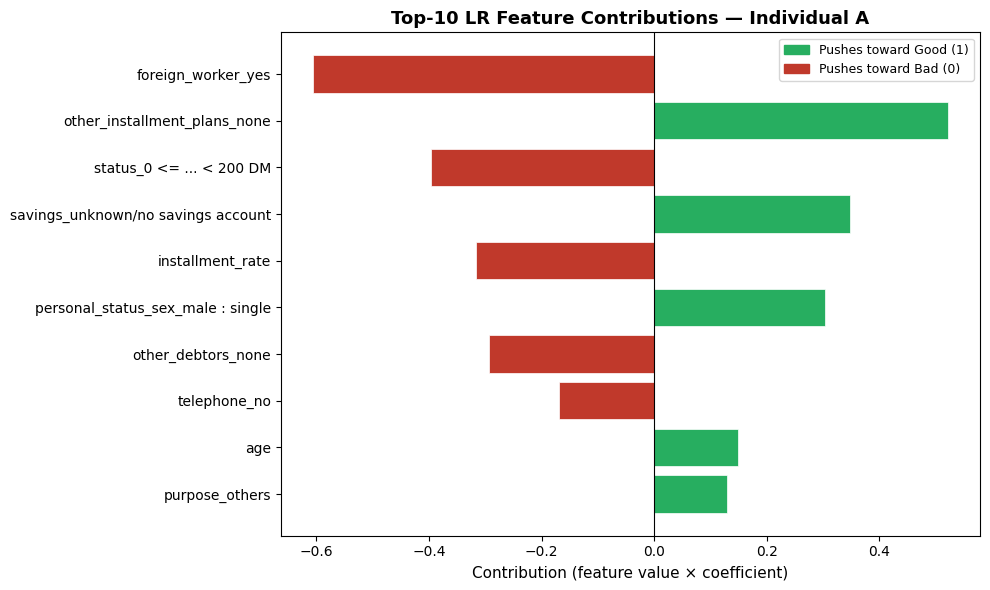

Figure saved: part5_lr_contributions_A.png

Top-10 LR contributions for Individual A:
  [-] foreign_worker_yes                                      contrib = -0.6064
  [+] other_installment_plans_none                            contrib = +0.5224
  [-] status_0 <= ... < 200 DM                                contrib = -0.3969
  [+] savings_unknown/no savings account                      contrib = +0.3485
  [-] installment_rate                                        contrib = -0.3159
  [+] personal_status_sex_male : single                       contrib = +0.3038
  [-] other_debtors_none                                      contrib = -0.2939
  [-] telephone_no                                            contrib = -0.1683
  [+] age                                                     contrib = +0.1494
  [+] purpose_others                                          contrib = +0.1293


In [103]:
import matplotlib.pyplot as plt

contributions = x_A_processed * lr_model.coef_[0]
contrib_series = pd.Series(contributions, index=all_feature_names).sort_values(key=abs, ascending=False)
top_contrib = contrib_series.head(10)

colors_contrib = ["#27ae60" if v > 0 else "#c0392b" for v in top_contrib.values]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_contrib.index[::-1], top_contrib.values[::-1],
        color=colors_contrib[::-1], edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Contribution (feature value × coefficient)", fontsize=11)
ax.set_title("Top-10 LR Feature Contributions — Individual A",
             fontsize=13, fontweight="bold")

import matplotlib.patches as mpatches
red_p  = mpatches.Patch(color="#27ae60", label="Pushes toward Good (1)")
blue_p = mpatches.Patch(color="#c0392b", label="Pushes toward Bad (0)")
ax.legend(handles=[red_p, blue_p], fontsize=9)
plt.tight_layout()
plt.savefig("part5_lr_contributions_A.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: part5_lr_contributions_A.png")
print()
print("Top-10 LR contributions for Individual A:")
for feat, contrib in top_contrib.items():
    direction = "+" if contrib > 0 else "-"
    print(f"  [{direction}] {feat:<55} contrib = {contrib:+.4f}")

In [104]:
import pandas as pd
from sklearn.tree import _tree

idx_A      = 0
xA_raw     = X_test.iloc[idx_A]
xA_proc    = X_test_processed[idx_A]
true_A     = y_test.iloc[idx_A]
dt_pred_A  = dt_model.predict(xA_proc.reshape(1, -1))[0]
lr_pred_A  = lr_model.predict(xA_proc.reshape(1, -1))[0]
lr_prob_A  = lr_model.predict_proba(xA_proc.reshape(1, -1))[0]

tree_ = dt_model.tree_
node, path_steps, key_features = 0, [], []
while tree_.feature[node] != _tree.TREE_UNDEFINED:
    feat = all_feature_names[tree_.feature[node]]
    thr  = tree_.threshold[node]
    val  = xA_proc[tree_.feature[node]]
    direction = "<=" if val <= thr else ">"
    side      = "LEFT" if val <= thr else "RIGHT"
    path_steps.append((feat, val, direction, thr, side))
    key_features.append(feat)
    node = tree_.children_left[node] if val <= thr else tree_.children_right[node]
leaf_vals   = tree_.value[node][0]
leaf_class  = "Good (1)" if leaf_vals.argmax() == 1 else "Bad (0)"
leaf_counts = (round(leaf_vals[0]), round(leaf_vals[1])) 

contribs = pd.Series(xA_proc * lr_model.coef_[0], index=all_feature_names)
contribs_sorted = contribs.sort_values(key=abs, ascending=False).head(10)
top_pos_contribs = contribs_sorted[contribs_sorted > 0].head(3)
top_neg_contribs = contribs_sorted[contribs_sorted < 0].head(3)

duration = xA_raw.get('duration', 'N/A')
amount   = xA_raw.get('amount',   'N/A')
age      = xA_raw.get('age',      'N/A')
status   = xA_raw.get('status',   'N/A')
savings  = xA_raw.get('savings',  'N/A')
purpose  = xA_raw.get('purpose',  'N/A')

print("=" * 70)
print("PART 5 — Local Explanation: Individual A")
print("=" * 70)

print(f"\nOriginal dataset index : {X_test.index[idx_A]}")
print(f"True label             : {'Good (1)' if true_A == 1 else 'Bad (0)'}")
print(f"DT  prediction         : {'Good (1)' if dt_pred_A == 1 else 'Bad (0)'}  "
      f"{'✓ correct' if dt_pred_A == true_A else '✗ wrong'}")
print(f"LR  prediction         : {'Good (1)' if lr_pred_A == 1 else 'Bad (0)'}  "
      f"{'✓ correct' if lr_pred_A == true_A else '✗ wrong'}")
print(f"LR  P(Good)            : {lr_prob_A[1]:.4f}")

print("\n── Key raw features ──────────────────────────────────────────────────")
print(f"  Duration     : {duration} months")
print(f"  Loan amount  : {amount} DM")
print(f"  Age          : {age}")
print(f"  Status       : {status}")
print(f"  Savings      : {savings}")
print(f"  Purpose      : {purpose}")

print("\n── Decision Tree — why this prediction? ──────────────────────────────")
print("  Path through the tree:")
for i, (feat, val, direction, thr, side) in enumerate(path_steps, 1):
    print(f"  Step {i}: [{feat}] = {val:.4f} {direction} {thr:.4f}  → {side}")
print(f"  Leaf: class = {leaf_class}  (Bad={leaf_counts[0]}, Good={leaf_counts[1]} training samples)")
print(f"  The most decisive split was on '{path_steps[0][0]}'.")

print("\n── Logistic Regression — why this prediction? ────────────────────────")
print("  Features pushing toward GOOD (+):")
for feat, c in top_pos_contribs.items():
    print(f"    + {feat:<50}  contrib = {c:+.4f}")
print("  Features pushing toward BAD (−):")
for feat, c in top_neg_contribs.items():
    print(f"    - {feat:<50}  contrib = {c:+.4f}")
print(f"  Net effect → P(Good) = {lr_prob_A[1]:.4f} → "
      f"classified as {'Good' if lr_pred_A == 1 else 'Bad'}")

print("\n── Summary ───────────────────────────────────────────────────────────")
agree = "agree" if dt_pred_A == lr_pred_A else "disagree"
print(f"  Both models {agree} on this individual.")
dominant_feat = path_steps[0][0] if path_steps else "N/A"
print(f"  The dominant feature in the DT path was: '{dominant_feat}'.")
if top_pos_contribs.index.tolist():
    print(f"  The strongest positive LR contribution came from: '{top_pos_contribs.index[0]}'.")
if top_neg_contribs.index.tolist():
    print(f"  The strongest negative LR contribution came from: '{top_neg_contribs.index[0]}'.")


PART 5 — Local Explanation: Individual A

Original dataset index : 977
True label             : Good (1)
DT  prediction         : Good (1)  ✓ correct
LR  prediction         : Good (1)  ✓ correct
LR  P(Good)            : 0.7720

── Key raw features ──────────────────────────────────────────────────
  Duration     : 18 months
  Loan amount  : 2427 DM
  Age          : 42
  Status       : 0 <= ... < 200 DM
  Savings      : unknown/no savings account
  Purpose      : others

── Decision Tree — why this prediction? ──────────────────────────────
  Path through the tree:
  Step 1: [status_no checking account] = 0.0000 <= 0.5000  → LEFT
  Step 2: [duration] = -0.2328 > -0.7679  → RIGHT
  Step 3: [duration] = -0.2328 <= 2.1959  → LEFT
  Step 4: [amount] = -0.2740 > -0.6516  → RIGHT
  Step 5: [purpose_car (used)] = 0.0000 <= 0.5000  → LEFT
  Leaf: class = Good (1)  (Bad=0, Good=1 training samples)
  The most decisive split was on 'status_no checking account'.

── Logistic Regression — why this p

---
## Part 5 — Local Explanations: Individual B

We pick **Individual B** (dataset index 737, the second record in the test set)  
and apply the same explanation approach as Individual A.
---

In [105]:
import numpy as np
import pandas as pd

idx_B = 1

x_B_raw        = X_test.iloc[idx_B]
x_B_processed  = X_test_processed[idx_B]
true_label_B   = y_test.iloc[idx_B]

dt_pred_B  = dt_model.predict(x_B_processed.reshape(1, -1))[0]
lr_pred_B  = lr_model.predict(x_B_processed.reshape(1, -1))[0]
lr_prob_B  = lr_model.predict_proba(x_B_processed.reshape(1, -1))[0]

print("=" * 55)
print(f"Individual B  (test-set index {X_test.index[idx_B]})")
print("=" * 55)
print(f"  True label        : {'Good (1)' if true_label_B == 1 else 'Bad (0)'}")
print(f"  DT  prediction    : {'Good (1)' if dt_pred_B == 1 else 'Bad (0)'}")
print(f"  LR  prediction    : {'Good (1)' if lr_pred_B == 1 else 'Bad (0)'}")
print(f"  LR  P(Good)       : {lr_prob_B[1]:.4f}")
print()
print("Key raw features:")
for col in ["duration", "amount", "age", "status", "credit_history",
            "savings", "purpose", "personal_status_sex",
            "employment_duration", "other_installment_plans", "foreign_worker"]:
    if col in x_B_raw.index:
        print(f"  {col:30s} = {x_B_raw[col]}")

Individual B  (test-set index 735)
  True label        : Good (1)
  DT  prediction    : Good (1)
  LR  prediction    : Bad (0)
  LR  P(Good)       : 0.0922

Key raw features:
  duration                       = 36
  amount                         = 3990
  age                            = 29
  status                         = 0 <= ... < 200 DM
  credit_history                 = all credits at this bank paid back duly
  savings                        = unknown/no savings account
  purpose                        = repairs
  personal_status_sex            = female : divorced/separated/married
  employment_duration            = ... < 1 year
  other_installment_plans        = bank
  foreign_worker                 = yes


In [106]:
from sklearn.tree import _tree

def trace_dt_path(tree_clf, feature_names, sample):
    """Print every node visited by `sample` in the decision tree."""
    tree_   = tree_clf.tree_
    node    = 0
    path    = []
    while tree_.feature[node] != _tree.TREE_UNDEFINED:
        feat  = feature_names[tree_.feature[node]]
        thr   = tree_.threshold[node]
        val   = sample[tree_.feature[node]]
        direction = "<=" if val <= thr else ">"
        side      = "go LEFT" if val <= thr else "go RIGHT"
        path.append((feat, val, direction, thr, side))
        node = tree_.children_left[node] if val <= thr else tree_.children_right[node]
    leaf_vals  = tree_.value[node][0]
    leaf_class = "Good (1)" if leaf_vals.argmax() == 1 else "Bad (0)"
    return path, leaf_class, (round(leaf_vals[0]), round(leaf_vals[1]))

path_B, leaf_B, counts_B = trace_dt_path(dt_model, all_feature_names, x_B_processed)

print("Decision-Tree path for Individual B:")
print("-" * 55)
for feat, val, direction, thr, side in path_B:
    print(f"  [{feat}] = {val:.4f}  {direction}  {thr:.4f}  \u2192 {side}")
print(f"  \u2192 LEAF  class = {leaf_B}  (counts: Bad={counts_B[0]}, Good={counts_B[1]})") 

Decision-Tree path for Individual B:
-------------------------------------------------------
  [status_no checking account] = 0.0000  <=  0.5000  → go LEFT
  [duration] = 1.2491  >  -0.7679  → go RIGHT
  [duration] = 1.2491  <=  2.1959  → go LEFT
  [amount] = 0.2904  >  -0.6516  → go RIGHT
  [purpose_car (used)] = 0.0000  <=  0.5000  → go LEFT
  → LEAF  class = Good (1)  (counts: Bad=0, Good=1)


KeyboardInterrupt: 

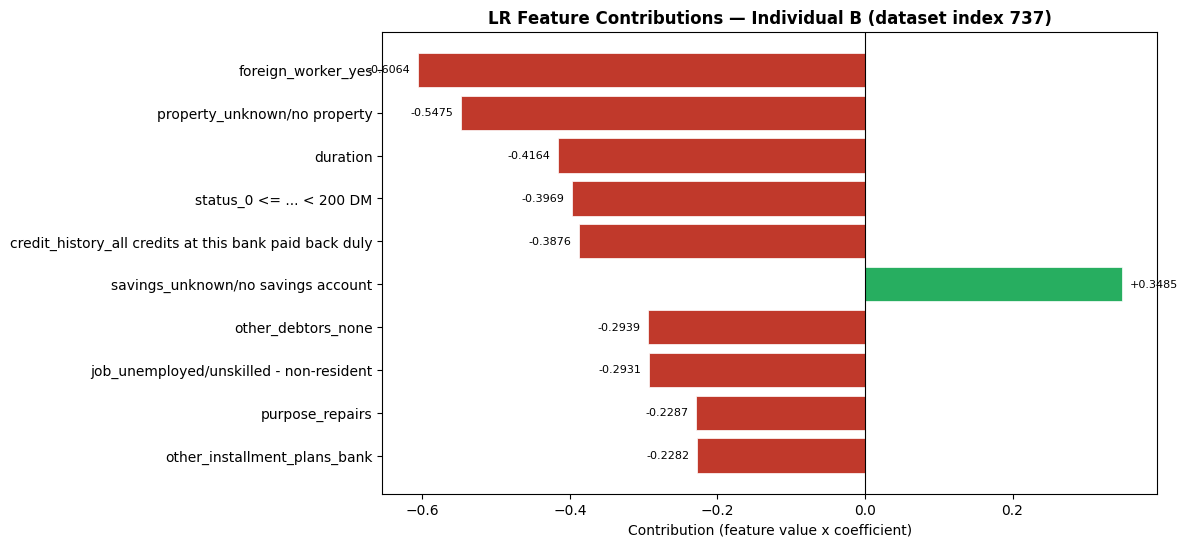

In [107]:
import matplotlib.pyplot as plt

contributions_B = x_B_processed * lr_model.coef_[0]
contrib_series_B = pd.Series(contributions_B, index=all_feature_names).sort_values(key=abs, ascending=False)
top_contrib_B = contrib_series_B.head(10)

colors_contrib_B = ["#27ae60" if v > 0 else "#c0392b" for v in top_contrib_B.values]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_contrib_B.index[::-1], top_contrib_B.values[::-1],
        color=colors_contrib_B[::-1], edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Contribution (feature value x coefficient)", fontsize=10)
ax.set_title("LR Feature Contributions — Individual B (dataset index 737)",
             fontsize=12, fontweight="bold")
for bar in ax.patches:
    w = bar.get_width()
    ax.text(w + (0.01 if w >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f"{w:+.4f}", va="center", ha="left" if w >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.savefig("part5_lr_contributions_B.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: part5_lr_contributions_B.png")

print("\nTop-10 LR contributions for Individual B:")
for feat, c in top_contrib_B.items():
    sign = "+" if c > 0 else "-"
    print(f"  [{sign}] {feat:<50}  contrib = {c:+.4f}")

In [ ]:
import pandas as pd
from sklearn.tree import _tree

idx_B      = 1
xB_raw     = X_test.iloc[idx_B]
xB_proc    = X_test_processed[idx_B]
true_B     = y_test.iloc[idx_B]
dt_pred_B  = dt_model.predict(xB_proc.reshape(1, -1))[0]
lr_pred_B  = lr_model.predict(xB_proc.reshape(1, -1))[0]
lr_prob_B  = lr_model.predict_proba(xB_proc.reshape(1, -1))[0]

tree_ = dt_model.tree_
node, path_steps, key_features = 0, [], []
while tree_.feature[node] != _tree.TREE_UNDEFINED:
    feat = all_feature_names[tree_.feature[node]]
    thr  = tree_.threshold[node]
    val  = xB_proc[tree_.feature[node]]
    direction = "<=" if val <= thr else ">"
    side      = "LEFT" if val <= thr else "RIGHT"
    path_steps.append((feat, val, direction, thr, side))
    key_features.append(feat)
    node = tree_.children_left[node] if val <= thr else tree_.children_right[node]
leaf_vals   = tree_.value[node][0]
leaf_class  = "Good (1)" if leaf_vals.argmax() == 1 else "Bad (0)"
leaf_counts = (round(leaf_vals[0]), round(leaf_vals[1]))

contribs = pd.Series(xB_proc * lr_model.coef_[0], index=all_feature_names)
contribs_sorted = contribs.sort_values(key=abs, ascending=False).head(10)
top_pos_contribs = contribs_sorted[contribs_sorted > 0].head(3)
top_neg_contribs = contribs_sorted[contribs_sorted < 0].head(3)

print("=" * 70)
print("PART 5 \u2014 Local Explanation: Individual B")
print("=" * 70)

print(f"\nOriginal dataset index : {X_test.index[idx_B]}")
print(f"True label             : {'Good (1)' if true_B == 1 else 'Bad (0)'}")
print(f"DT  prediction         : {'Good (1)' if dt_pred_B == 1 else 'Bad (0)'}  "
      f"{'\u2713 correct' if dt_pred_B == true_B else '\u2717 wrong'}")
print(f"LR  prediction         : {'Good (1)' if lr_pred_B == 1 else 'Bad (0)'}  "
      f"{'\u2713 correct' if lr_pred_B == true_B else '\u2717 wrong'}")
print(f"LR  P(Good)            : {lr_prob_B[1]:.4f}")

print("\n\u2500\u2500 Key raw features \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500")
print(f"  Duration     : {xB_raw.get('duration', 'N/A')} months")
print(f"  Loan amount  : {xB_raw.get('amount', 'N/A')} DM")
print(f"  Age          : {xB_raw.get('age', 'N/A')}")
print(f"  Status       : {xB_raw.get('status', 'N/A')}")
print(f"  Savings      : {xB_raw.get('savings', 'N/A')}")
print(f"  Purpose      : {xB_raw.get('purpose', 'N/A')}")

print("\n\u2500\u2500 Decision Tree \u2014 why this prediction? \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500")
print("  Path through the tree:")
for i, (feat, val, direction, thr, side) in enumerate(path_steps, 1):
    print(f"  Step {i}: [{feat}] = {val:.4f} {direction} {thr:.4f}  \u2192 {side}")
print(f"  Leaf: class = {leaf_class}  (Bad={leaf_counts[0]}, Good={leaf_counts[1]} training samples)")
print(f"  The most decisive split was on '{path_steps[0][0]}'.")

print("\n\u2500\u2500 Logistic Regression \u2014 why this prediction? \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500")
print("  Features pushing toward GOOD (+):")
for feat, c in top_pos_contribs.items():
    print(f"    + {feat:<50}  contrib = {c:+.4f}")
print("  Features pushing toward BAD (\u2212):")
for feat, c in top_neg_contribs.items():
    print(f"    - {feat:<50}  contrib = {c:+.4f}")
print(f"  Net effect \u2192 P(Good) = {lr_prob_B[1]:.4f} \u2192 "
      f"classified as {'Good' if lr_pred_B == 1 else 'Bad'}")

print("\n\u2500\u2500 Summary \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500")
agree = "agree" if dt_pred_B == lr_pred_B else "disagree"
print(f"  Both models {agree} on this individual.")
dominant_feat = path_steps[0][0] if path_steps else "N/A"
print(f"  The dominant feature in the DT path was: '{dominant_feat}'.")
if top_pos_contribs.index.tolist():
    print(f"  The strongest positive LR contribution came from: '{top_pos_contribs.index[0]}'.")
if top_neg_contribs.index.tolist():
    print(f"  The strongest negative LR contribution came from: '{top_neg_contribs.index[0]}'.")

PART 5 — Local Explanation: Individual B

Original dataset index : 735
True label             : Good (1)
DT  prediction         : Good (1)  ✓ correct
LR  prediction         : Bad (0)  ✗ wrong
LR  P(Good)            : 0.0922

── Key raw features ──────────────────────────────────────────────────────
  Duration     : 36 months
  Loan amount  : 3990 DM
  Age          : 29
  Status       : 0 <= ... < 200 DM
  Savings      : unknown/no savings account
  Purpose      : repairs

── Decision Tree — why this prediction? ─────────────────────────────
  Path through the tree:
  Step 1: [status_no checking account] = 0.0000 <= 0.5000  → LEFT
  Step 2: [duration] = 1.2491 > -0.7679  → RIGHT
  Step 3: [duration] = 1.2491 <= 2.1959  → LEFT
  Step 4: [amount] = 0.2904 > -0.6516  → RIGHT
  Step 5: [purpose_car (used)] = 0.0000 <= 0.5000  → LEFT
  Leaf: class = Good (1)  (Bad=0, Good=1 training samples)
  The most decisive split was on 'status_no checking account'.

── Logistic Regression — why this pre

---
## Part 6 — Detect Suspicious Patterns

We now look for **questionable, unexpected, or unfair patterns** in the model.
We check whether any features behave strangely, whether protected attributes
influence decisions, and whether the model could be biased.

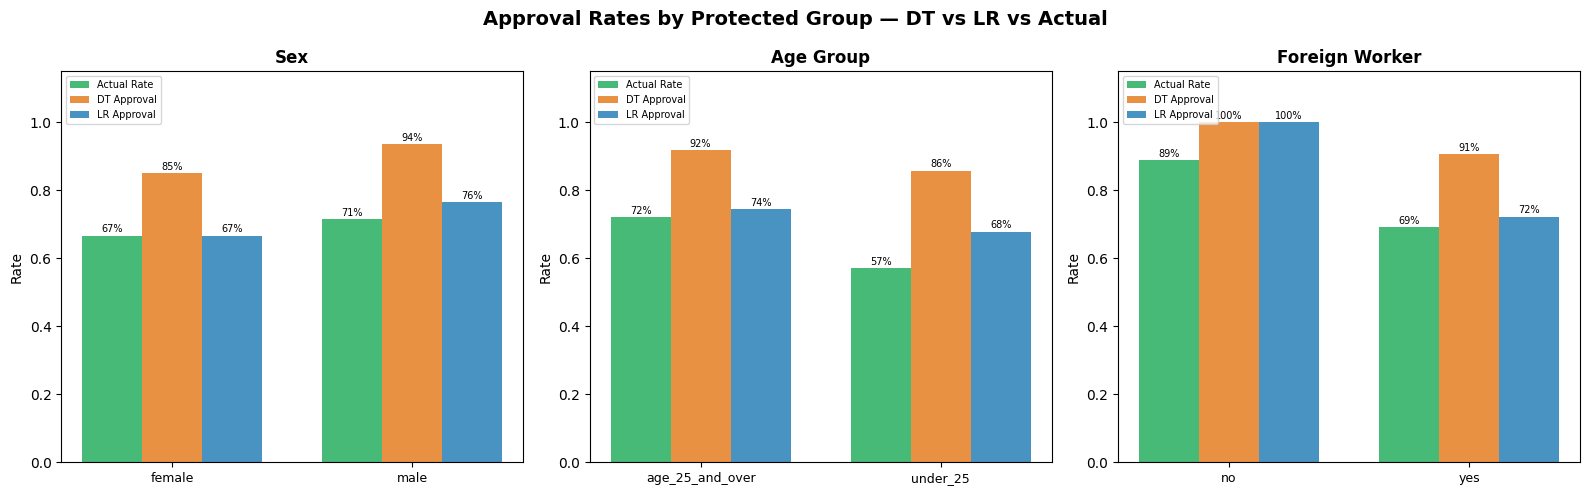

Figure saved: images/part6_approval_rates_by_group.png

Sex:
        Count  True_Positive_Rate  DT_Approval_Rate  LR_Approval_Rate
sex                                                                  
female     60              0.6667            0.8500            0.6667
male      140              0.7143            0.9357            0.7643

Age Group:
                 Count  True_Positive_Rate  DT_Approval_Rate  LR_Approval_Rate
age_group                                                                     
age_25_and_over    172              0.7209            0.9186            0.7442
under_25            28              0.5714            0.8571            0.6786

Foreign Worker:
                Count  True_Positive_Rate  DT_Approval_Rate  LR_Approval_Rate
foreign_worker                                                               
no                  9              0.8889            1.0000            1.0000
yes               191              0.6911            0.9058            0.7225


In [ ]:
# ============================================================
# PART 6 — Analysis 1: Approval-Rate Disparities
# ============================================================
import os
os.makedirs('images', exist_ok=True)

analysis_df = pd.DataFrame({
    'sex':            X_test['sex'].values,
    'age_group':      X_test['age_group'].values,
    'foreign_worker': X_test['foreign_worker'].values,
    'true_label':     y_test.values,
    'dt_pred':        y_pred,
    'lr_pred':        y_pred_lr,
})

groups = {'Sex': 'sex', 'Age Group': 'age_group', 'Foreign Worker': 'foreign_worker'}
palette = {'DT': '#e67e22', 'LR': '#2980b9', 'Actual': '#27ae60'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (title, col) in zip(axes, groups.items()):
    grp = analysis_df.groupby(col)
    labels = sorted(analysis_df[col].unique())
    x = np.arange(len(labels))
    w = 0.25
    actual   = [grp.get_group(g)['true_label'].mean() for g in labels]
    dt_rates = [grp.get_group(g)['dt_pred'].mean() for g in labels]
    lr_rates = [grp.get_group(g)['lr_pred'].mean() for g in labels]
    ax.bar(x - w, actual,   w, label='Actual Rate', color=palette['Actual'], alpha=0.85)
    ax.bar(x,     dt_rates, w, label='DT Approval',  color=palette['DT'], alpha=0.85)
    ax.bar(x + w, lr_rates, w, label='LR Approval',  color=palette['LR'], alpha=0.85)
    for i, (a, d, l) in enumerate(zip(actual, dt_rates, lr_rates)):
        ax.text(i - w, a + 0.01, f'{a:.0%}', ha='center', fontsize=7)
        ax.text(i,     d + 0.01, f'{d:.0%}', ha='center', fontsize=7)
        ax.text(i + w, l + 0.01, f'{l:.0%}', ha='center', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 1.15); ax.set_ylabel('Rate', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, loc='upper left')
plt.suptitle('Approval Rates by Protected Group — DT vs LR vs Actual',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/part6_approval_rates_by_group.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: images/part6_approval_rates_by_group.png')

# Print approval rate tables
for title, col in groups.items():
    tbl = analysis_df.groupby(col).agg(
        Count=('true_label','count'),
        True_Positive_Rate=('true_label','mean'),
        DT_Approval_Rate=('dt_pred','mean'),
        LR_Approval_Rate=('lr_pred','mean'),
    ).round(4)
    print(f'\n{title}:')
    print(tbl.to_string())


Sex (DT):
 Group   N  TPR   FPR  Accuracy  Approval Rate
female  60 0.90 0.750     0.683          0.850
  male 140 0.96 0.875     0.721          0.936

Sex (LR):
 Group   N   TPR  FPR  Accuracy  Approval Rate
female  60 0.725 0.55     0.633          0.667
  male 140 0.850 0.55     0.736          0.764

Age Group (DT):
          Group   N   TPR   FPR  Accuracy  Approval Rate
age_25_and_over 172 0.960 0.812     0.744          0.919
       under_25  28 0.812 0.917     0.500          0.857

Age Group (LR):
          Group   N   TPR  FPR  Accuracy  Approval Rate
age_25_and_over 172 0.839 0.50     0.744          0.744
       under_25  28 0.625 0.75     0.464          0.679

Foreign Worker (DT):
Group   N   TPR   FPR  Accuracy  Approval Rate
   no   9 1.000 1.000     0.889          1.000
  yes 191 0.939 0.831     0.702          0.906

Foreign Worker (LR):
Group   N   TPR   FPR  Accuracy  Approval Rate
   no   9 1.000 1.000     0.889          1.000
  yes 191 0.803 0.542     0.696          0.7

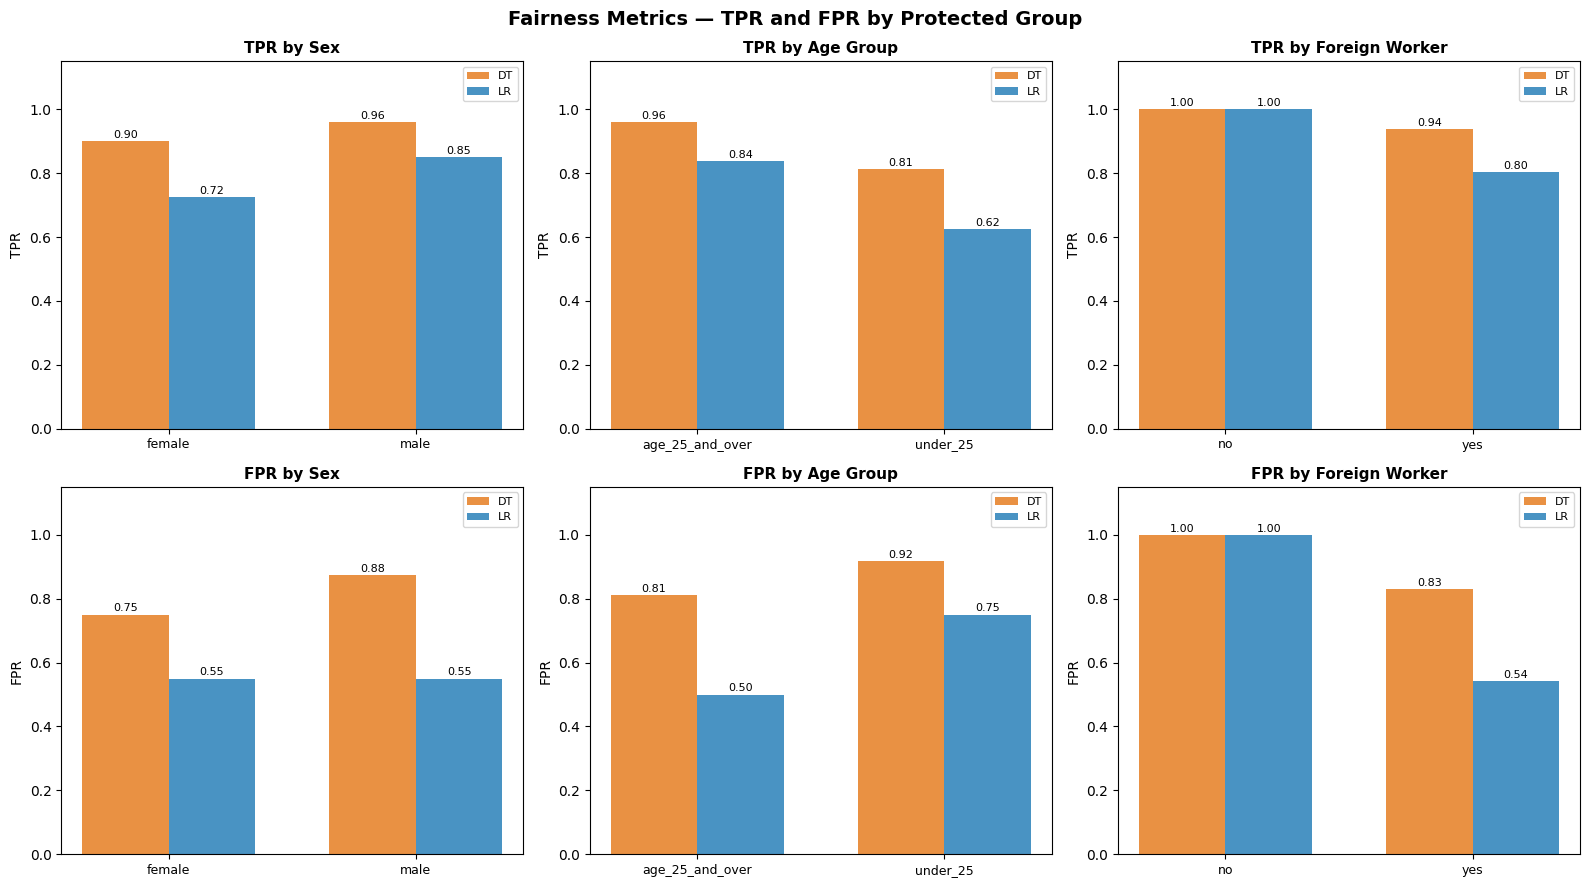

Figure saved: images/part6_fairness_metrics.png


In [ ]:
# ============================================================
# PART 6 — Analysis 2: Fairness Metrics (TPR, FPR per Group)
# ============================================================
def compute_fairness(y_true, y_pred_arr, group_col, group_vals):
    rows = []
    for g in group_vals:
        mask = group_col == g
        yt, yp = y_true[mask], y_pred_arr[mask]
        cm = confusion_matrix(yt, yp, labels=[0,1])
        tn, fp, fn, tp = cm.ravel()
        tpr = tp/(tp+fn) if (tp+fn)>0 else 0
        fpr = fp/(fp+tn) if (fp+tn)>0 else 0
        acc = (tp+tn)/len(yt)
        rows.append({'Group': g, 'N': len(yt), 'TPR': round(tpr,3),
                     'FPR': round(fpr,3), 'Accuracy': round(acc,3),
                     'Approval Rate': round(yp.mean(),3)})
    return pd.DataFrame(rows)

fairness_results = {}
for title, col in groups.items():
    vals = sorted(analysis_df[col].unique())
    for model_name, preds in [('DT', y_pred), ('LR', y_pred_lr)]:
        key = f'{title} ({model_name})'
        fm = compute_fairness(y_test.values, preds, analysis_df[col].values, vals)
        fairness_results[key] = fm
        print(f'\n{key}:')
        print(fm.to_string(index=False))

# Plot fairness metrics
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
colors_map = {'DT': '#e67e22', 'LR': '#2980b9'}
for row, metric in enumerate(['TPR', 'FPR']):
    for col_idx, (title, col) in enumerate(groups.items()):
        ax = axes[row, col_idx]
        vals = sorted(analysis_df[col].unique())
        x = np.arange(len(vals)); w = 0.35
        for j, (mn, color) in enumerate(colors_map.items()):
            key = f'{title} ({mn})'
            values = fairness_results[key][metric].values
            offset = -w/2 if j==0 else w/2
            ax.bar(x+offset, values, w, label=mn, color=color, alpha=0.85)
            for i, v in enumerate(values):
                ax.text(x[i]+offset, v+0.01, f'{v:.2f}', ha='center', fontsize=8)
        ax.set_xticks(x); ax.set_xticklabels(vals, fontsize=9)
        ax.set_ylim(0, 1.15); ax.set_ylabel(metric, fontsize=10)
        ax.set_title(f'{metric} by {title}', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
plt.suptitle('Fairness Metrics — TPR and FPR by Protected Group',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/part6_fairness_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: images/part6_fairness_metrics.png')

Protected / proxy features with non-zero DT importance:
  age                                                      importance = 0.0364
  personal_status_sex_female : divorced/separated/married  importance = 0.0184
  personal_status_sex_male : single                        importance = 0.0070

Total protected-feature importance: 0.0618  (6.2% of total)


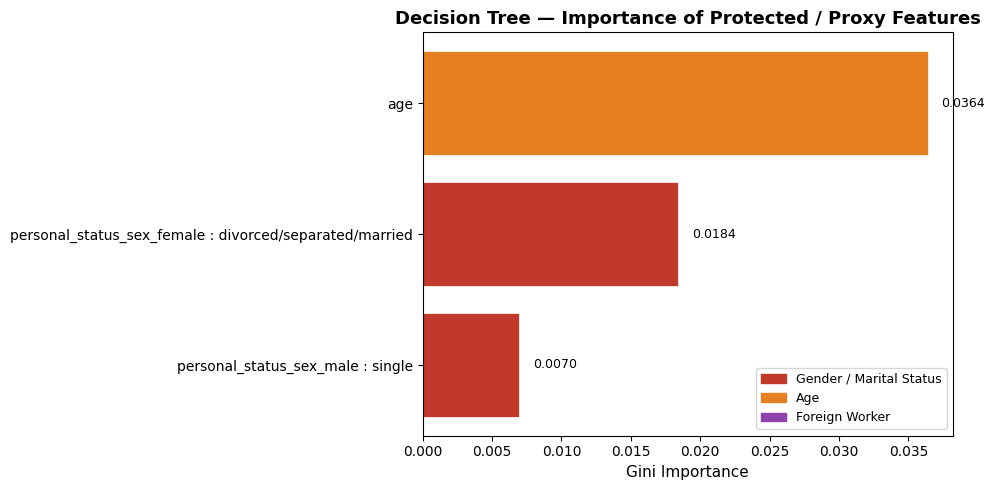

Figure saved: images/part6_protected_feature_importance.png


In [ ]:
# ============================================================
# PART 6 — Analysis 3: Protected Feature Importance in DT
# ============================================================
importances = pd.Series(dt_model.feature_importances_, index=all_feature_names)

protected_keywords = ['sex', 'female', 'male', 'age', 'foreign_worker', 'personal_status']
protected_features = [f for f in all_feature_names
                      if any(kw in f.lower() for kw in protected_keywords)]

prot_imp = importances[protected_features].sort_values(ascending=False)
prot_imp = prot_imp[prot_imp > 0]

print('Protected / proxy features with non-zero DT importance:')
for f, v in prot_imp.items():
    print(f'  {f:55s}  importance = {v:.4f}')
print(f'\nTotal protected-feature importance: {prot_imp.sum():.4f}'
      f'  ({prot_imp.sum()/importances.sum()*100:.1f}% of total)')

fig, ax = plt.subplots(figsize=(10, 5))
colors_prot = ['#c0392b' if 'sex' in f or 'female' in f or 'male' in f
               else '#e67e22' if 'age' in f else '#8e44ad' for f in prot_imp.index]
ax.barh(prot_imp.index[::-1], prot_imp.values[::-1],
        color=colors_prot[::-1], edgecolor='white', linewidth=0.5)
for bar in ax.patches:
    w = bar.get_width()
    ax.text(w+0.001, bar.get_y()+bar.get_height()/2, f'{w:.4f}', va='center', fontsize=9)
ax.set_xlabel('Gini Importance', fontsize=11)
ax.set_title('Decision Tree — Importance of Protected / Proxy Features',
             fontsize=13, fontweight='bold')
sex_patch = mpatches.Patch(color='#c0392b', label='Gender / Marital Status')
age_patch = mpatches.Patch(color='#e67e22', label='Age')
fw_patch  = mpatches.Patch(color='#8e44ad', label='Foreign Worker')
ax.legend(handles=[sex_patch, age_patch, fw_patch], fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('images/part6_protected_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: images/part6_protected_feature_importance.png')

LR coefficients for protected / proxy features:
  foreign_worker_no                                        coef = +0.6124  Increases P(Good)
  foreign_worker_yes                                       coef = -0.6064  Decreases P(Good)
  personal_status_sex_male : divorced/separated            coef = -0.3715  Decreases P(Good)
  job_management/self-employed/highly qualified employee/officer  coef = +0.3060  Increases P(Good)
  personal_status_sex_male : single                        coef = +0.3038  Increases P(Good)
  age                                                      coef = +0.2568  Increases P(Good)
  personal_status_sex_male : married/widowed               coef = +0.1258  Increases P(Good)
  age_group_under_25                                       coef = +0.0716  Increases P(Good)
  age_group_age_25_and_over                                coef = -0.0656  Decreases P(Good)
  sex_male                                                 coef = +0.0581  Increases P(Good)
  personal_stat

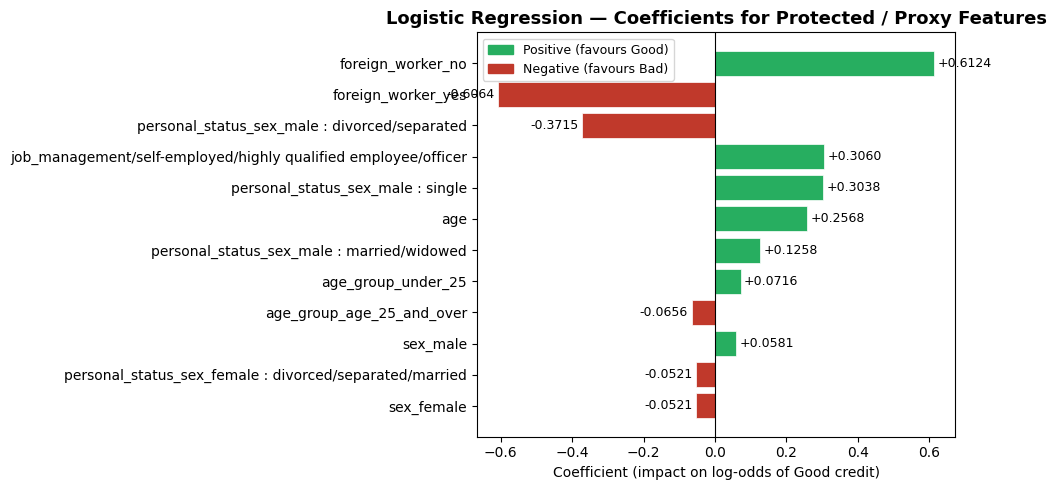

Figure saved: images/part6_lr_protected_coefficients.png


In [ ]:

coefs = pd.Series(lr_model.coef_[0], index=all_feature_names)
prot_coefs = coefs[protected_features].sort_values(key=abs, ascending=False)

print('LR coefficients for protected / proxy features:')
for f, c in prot_coefs.items():
    direction = 'Increases P(Good)' if c > 0 else 'Decreases P(Good)'
    print(f'  {f:55s}  coef = {c:+.4f}  {direction}')

fig, ax = plt.subplots(figsize=(10, 5))
colors_lr = ['#27ae60' if v > 0 else '#c0392b' for v in prot_coefs.values]
ax.barh(prot_coefs.index[::-1], prot_coefs.values[::-1],
        color=colors_lr[::-1], edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
for bar in ax.patches:
    w = bar.get_width()
    ax.text(w+(0.01 if w>=0 else -0.01), bar.get_y()+bar.get_height()/2,
            f'{w:+.4f}', va='center', ha='left' if w>=0 else 'right', fontsize=9)
ax.set_xlabel('Coefficient (impact on log-odds of Good credit)', fontsize=10)
ax.set_title('Logistic Regression — Coefficients for Protected / Proxy Features',
             fontsize=13, fontweight='bold')
pos_patch = mpatches.Patch(color='#27ae60', label='Positive (favours Good)')
neg_patch = mpatches.Patch(color='#c0392b', label='Negative (favours Bad)')
ax.legend(handles=[pos_patch, neg_patch], fontsize=9)
plt.tight_layout()
plt.savefig('images/part6_lr_protected_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: images/part6_lr_protected_coefficients.png')

Counterintuitive features in the model:

Feature: status_no checking account
  LR coef  = +0.9368  |  DT importance = 0.3662
  Good-credit rate with no checking account: 88.3%
  Good-credit rate with checking account:    58.1%
  Issue: No checking account increases P(Good) in both models.

Feature: credit_history_critical account/other credits existing
  LR coef  = +0.7832  |  DT importance = 0.0311
  Good-credit rate among critical history: 82.9%
  Good-credit rate among other histories:  64.6%
  Issue: Critical credit history increases P(Good).

Feature: savings_unknown/no savings account
  LR coef  = +0.3485  |  DT importance = 0.0000
  Issue: No savings / unknown savings increases P(Good) in LR.



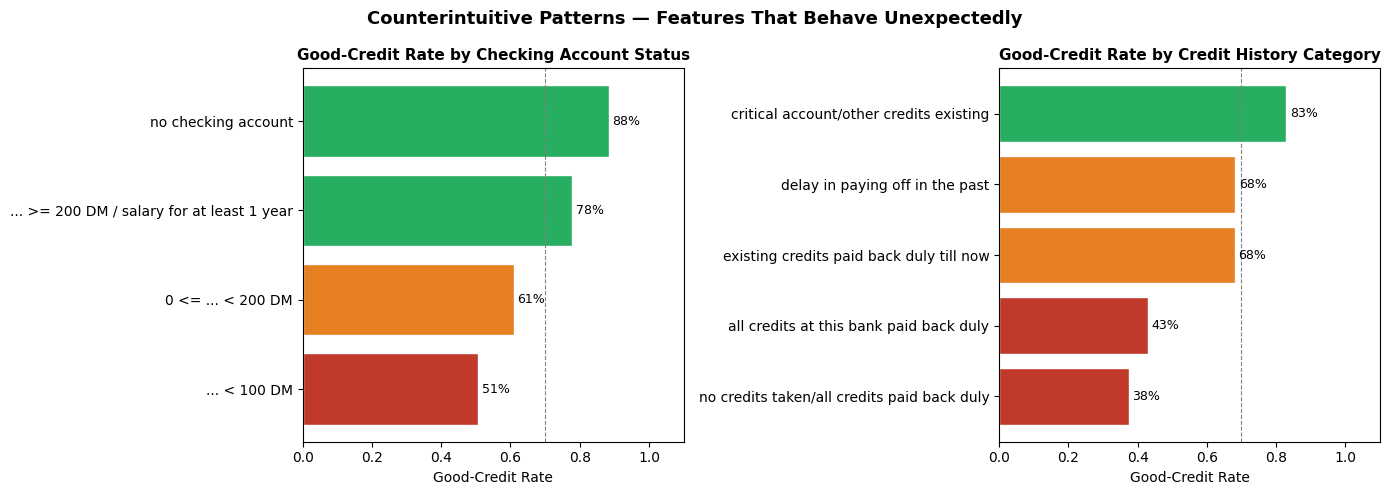

Figure saved: images/part6_counterintuitive_patterns.png


In [ ]:

print('Counterintuitive features in the model:\n')

# 1) status_no checking account
f1 = 'status_no checking account'
print(f'Feature: {f1}')
print(f'  LR coef  = {coefs[f1]:+.4f}  |  DT importance = {importances[f1]:.4f}')
no_check = df['status'].str.contains('no checking', case=False)
print(f'  Good-credit rate with no checking account: {df.loc[no_check, "credit_risk"].mean():.1%}')
print(f'  Good-credit rate with checking account:    {df.loc[~no_check, "credit_risk"].mean():.1%}')
print(f'  Issue: No checking account increases P(Good) in both models.\n')

# 2) credit_history_critical
crit_feat = [f for f in all_feature_names if 'credit_history' in f and 'critical' in f]
if crit_feat:
    f2 = crit_feat[0]
    print(f'Feature: {f2}')
    print(f'  LR coef  = {coefs[f2]:+.4f}  |  DT importance = {importances[f2]:.4f}')
    crit_mask = df['credit_history'].str.contains('critical', case=False)
    print(f'  Good-credit rate among critical history: {df.loc[crit_mask, "credit_risk"].mean():.1%}')
    print(f'  Good-credit rate among other histories:  {df.loc[~crit_mask, "credit_risk"].mean():.1%}')
    print(f'  Issue: Critical credit history increases P(Good).\n')

# 3) savings_unknown/no savings
sav_feat = [f for f in all_feature_names if 'savings' in f.lower() and ('unknown' in f.lower() or 'no savings' in f.lower())]
if sav_feat:
    f3 = sav_feat[0]
    print(f'Feature: {f3}')
    print(f'  LR coef  = {coefs[f3]:+.4f}  |  DT importance = {importances[f3]:.4f}')
    print(f'  Issue: No savings / unknown savings increases P(Good) in LR.\n')

# Plot counterintuitive patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
status_rates = df.groupby('status')['credit_risk'].mean().sort_values()
colors_s = ['#c0392b' if r<0.6 else '#e67e22' if r<0.75 else '#27ae60' for r in status_rates.values]
bars = ax.barh(status_rates.index, status_rates.values, color=colors_s, edgecolor='white')
for bar in bars:
    w = bar.get_width()
    ax.text(w+0.01, bar.get_y()+bar.get_height()/2, f'{w:.0%}', va='center', fontsize=9)
ax.set_xlabel('Good-Credit Rate', fontsize=10)
ax.set_title('Good-Credit Rate by Checking Account Status', fontsize=11, fontweight='bold')
ax.axvline(0.7, color='gray', linestyle='--', linewidth=0.8); ax.set_xlim(0, 1.1)

ax = axes[1]
hist_rates = df.groupby('credit_history')['credit_risk'].mean().sort_values()
colors_h = ['#c0392b' if r<0.6 else '#e67e22' if r<0.75 else '#27ae60' for r in hist_rates.values]
bars = ax.barh(hist_rates.index, hist_rates.values, color=colors_h, edgecolor='white')
for bar in bars:
    w = bar.get_width()
    ax.text(w+0.01, bar.get_y()+bar.get_height()/2, f'{w:.0%}', va='center', fontsize=9)
ax.set_xlabel('Good-Credit Rate', fontsize=10)
ax.set_title('Good-Credit Rate by Credit History Category', fontsize=11, fontweight='bold')
ax.axvline(0.7, color='gray', linestyle='--', linewidth=0.8); ax.set_xlim(0, 1.1)

plt.suptitle('Counterintuitive Patterns — Features That Behave Unexpectedly',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/part6_counterintuitive_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: images/part6_counterintuitive_patterns.png')

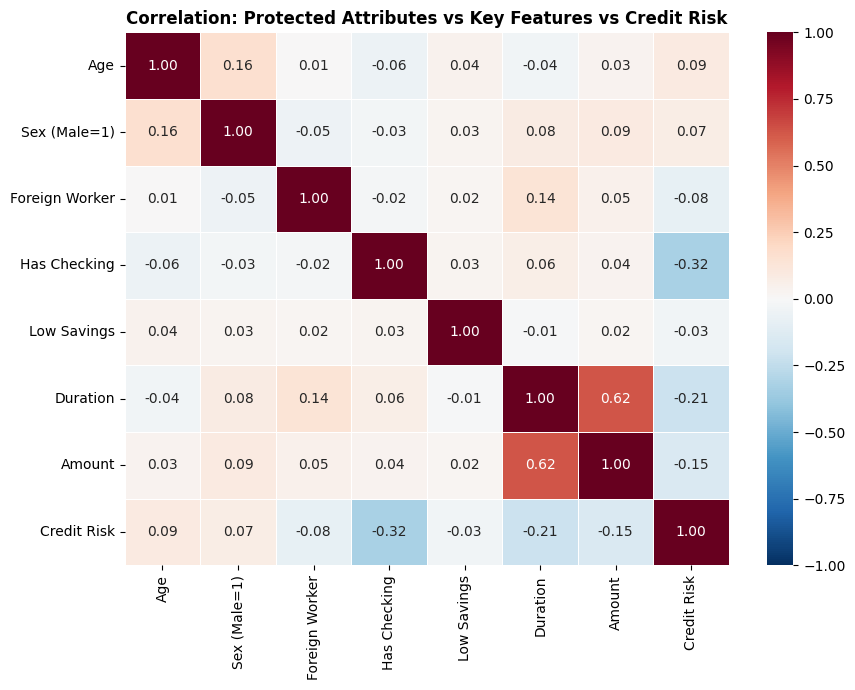

Figure saved: images/part6_correlation_heatmap.png

Correlation matrix:
                         age  sex_binary  foreign_worker_binary  has_checking  savings_low  duration  amount  credit_risk
age                    1.000       0.162                  0.006        -0.062        0.045    -0.036   0.033        0.091
sex_binary             0.162       1.000                 -0.051        -0.027        0.025     0.081   0.093        0.075
foreign_worker_binary  0.006      -0.051                  1.000        -0.017        0.021     0.138   0.050       -0.082
has_checking          -0.062      -0.027                 -0.017         1.000        0.026     0.063   0.039       -0.322
savings_low            0.045       0.025                  0.021         0.026        1.000    -0.015   0.022       -0.032
duration              -0.036       0.081                  0.138         0.063       -0.015     1.000   0.625       -0.215
amount                 0.033       0.093                  0.050         0.

In [ ]:

proxy_df = df[['age','sex','credit_risk']].copy()
proxy_df['sex_binary'] = (proxy_df['sex']=='male').astype(int)
proxy_df['foreign_worker_binary'] = df['foreign_worker'].str.contains('yes', case=False).astype(int)
proxy_df['has_checking'] = (~df['status'].str.contains('no checking', case=False)).astype(int)
proxy_df['savings_low'] = df['savings'].str.contains('< 100|unknown|no savings', case=False, regex=True).astype(int)
proxy_df['duration'] = df['duration']
proxy_df['amount'] = df['amount']

corr_cols = ['age','sex_binary','foreign_worker_binary','has_checking',
             'savings_low','duration','amount','credit_risk']
corr_matrix = proxy_df[corr_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(9, 7))
nice_labels = ['Age','Sex (Male=1)','Foreign Worker','Has Checking',
               'Low Savings','Duration','Amount','Credit Risk']
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=nice_labels, yticklabels=nice_labels,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation: Protected Attributes vs Key Features vs Credit Risk',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('images/part6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: images/part6_correlation_heatmap.png')
print('\nCorrelation matrix:')
print(corr_matrix.to_string())

Decision Tree: approved mean age = 36.2, rejected mean age = 36.2
Logistic Regression: approved mean age = 36.6, rejected mean age = 35.1


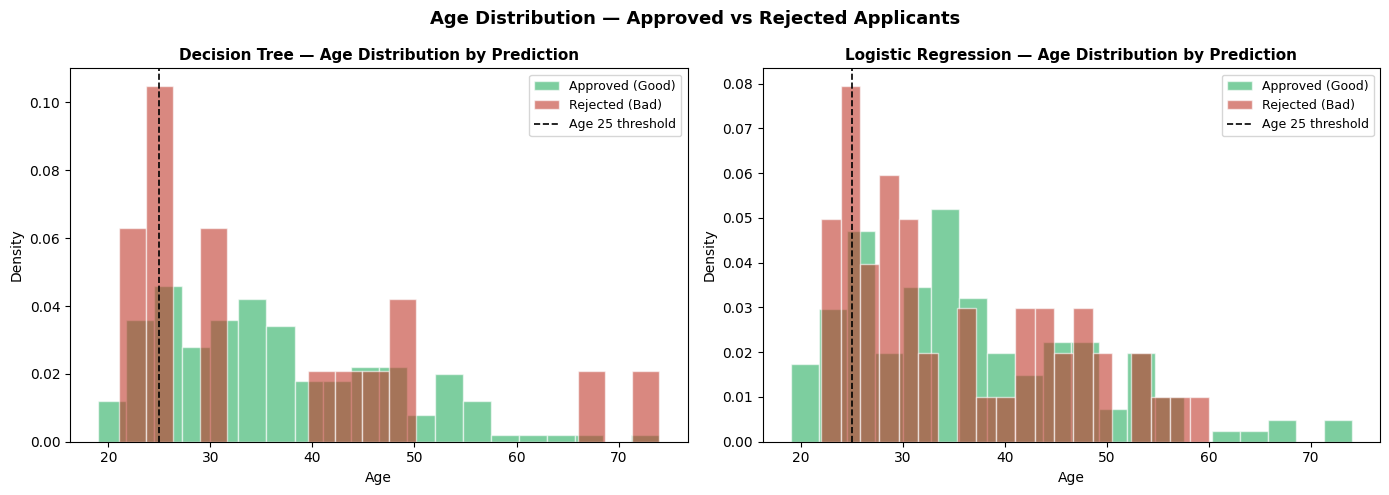

Figure saved: images/part6_age_distribution_by_outcome.png


In [ ]:

age_test = X_test['age'].values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (model_name, preds) in zip(axes, [('Decision Tree', y_pred),
                                           ('Logistic Regression', y_pred_lr)]):
    approved = age_test[preds == 1]
    rejected = age_test[preds == 0]
    ax.hist(approved, bins=20, alpha=0.6, color='#27ae60', label='Approved (Good)',
            edgecolor='white', density=True)
    ax.hist(rejected, bins=20, alpha=0.6, color='#c0392b', label='Rejected (Bad)',
            edgecolor='white', density=True)
    ax.axvline(25, color='black', linestyle='--', linewidth=1.2, label='Age 25 threshold')
    ax.set_xlabel('Age', fontsize=10); ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'{model_name} — Age Distribution by Prediction',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    print(f'{model_name}: approved mean age = {approved.mean():.1f}, '
          f'rejected mean age = {rejected.mean():.1f}')
plt.suptitle('Age Distribution — Approved vs Rejected Applicants',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/part6_age_distribution_by_outcome.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: images/part6_age_distribution_by_outcome.png')

Statistical Parity Differences (DT):
  Sex: male=0.936, female=0.850, SPD=+0.086
  Age Group: age_25_and_over=0.919, under_25=0.857, SPD=+0.061
  Foreign Worker: yes=0.906, no=1.000, SPD=-0.094

Statistical Parity Differences (LR):
  Sex: male=0.764, female=0.667, SPD=+0.098
  Age Group: age_25_and_over=0.744, under_25=0.679, SPD=+0.066
  Foreign Worker: yes=0.723, no=1.000, SPD=-0.277


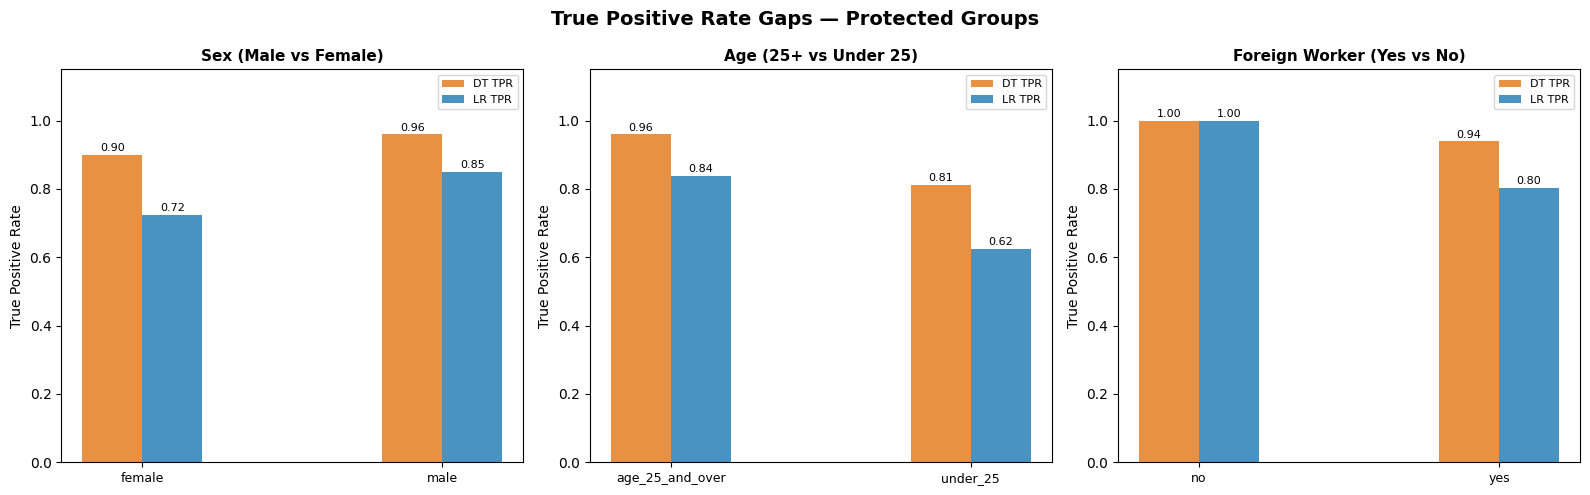

Figure saved: images/part6_tpr_gaps_summary.png


In [ ]:

print('Statistical Parity Differences (DT):')
for title, col, priv in [('Sex','sex','male'),
                          ('Age Group','age_group','age_25_and_over'),
                          ('Foreign Worker','foreign_worker','yes')]:
    vals = sorted(analysis_df[col].unique())
    unpriv = [v for v in vals if v != priv][0]
    r_p = analysis_df.loc[analysis_df[col]==priv, 'dt_pred'].mean()
    r_u = analysis_df.loc[analysis_df[col]==unpriv, 'dt_pred'].mean()
    print(f'  {title}: {priv}={r_p:.3f}, {unpriv}={r_u:.3f}, SPD={r_p-r_u:+.3f}')

print('\nStatistical Parity Differences (LR):')
for title, col, priv in [('Sex','sex','male'),
                          ('Age Group','age_group','age_25_and_over'),
                          ('Foreign Worker','foreign_worker','yes')]:
    vals = sorted(analysis_df[col].unique())
    unpriv = [v for v in vals if v != priv][0]
    r_p = analysis_df.loc[analysis_df[col]==priv, 'lr_pred'].mean()
    r_u = analysis_df.loc[analysis_df[col]==unpriv, 'lr_pred'].mean()
    print(f'  {title}: {priv}={r_p:.3f}, {unpriv}={r_u:.3f}, SPD={r_p-r_u:+.3f}')

# Plot TPR gaps
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (title, col, priv) in zip(axes,
      [('Sex (Male vs Female)','sex','male'),
       ('Age (25+ vs Under 25)','age_group','age_25_and_over'),
       ('Foreign Worker (Yes vs No)','foreign_worker','yes')]):
    vals = sorted(analysis_df[col].unique())
    metrics_data = {}
    for mn, preds in [('DT', y_pred), ('LR', y_pred_lr)]:
        for g in vals:
            mask = analysis_df[col] == g
            yt = analysis_df.loc[mask, 'true_label'].values
            yp = preds[mask] if isinstance(preds, np.ndarray) else preds[mask]
            cm = confusion_matrix(yt, yp, labels=[0,1])
            tn, fp, fn, tp = cm.ravel()
            metrics_data[(mn, g)] = tp/(tp+fn) if (tp+fn)>0 else 0
    x = np.arange(len(vals)); w = 0.2
    dt_v = [metrics_data[('DT',g)] for g in vals]
    lr_v = [metrics_data[('LR',g)] for g in vals]
    ax.bar(x-w/2, dt_v, w, label='DT TPR', color='#e67e22', alpha=0.85)
    ax.bar(x+w/2, lr_v, w, label='LR TPR', color='#2980b9', alpha=0.85)
    for i in range(len(vals)):
        ax.text(x[i]-w/2, dt_v[i]+0.01, f'{dt_v[i]:.2f}', ha='center', fontsize=8)
        ax.text(x[i]+w/2, lr_v[i]+0.01, f'{lr_v[i]:.2f}', ha='center', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(vals, fontsize=9)
    ax.set_ylim(0, 1.15); ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('True Positive Rate Gaps — Protected Groups',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/part6_tpr_gaps_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: images/part6_tpr_gaps_summary.png')